# Módulo de Análisis Univariante (`heavystats.univariate`)

Este cuaderno interactivo implementa y documenta la metodología completa de **análisis univariante** y caracterización basal de acuerdo con los ítems de la sección 3 del protocolo de investigación de metales pesados en población infantil (normas STROBE / ICMJE / CDC).

### Objetivos Metodológicos y Estadísticos
1. **Caracterización de Variables Categóricas**: Frecuencias absolutas y relativas $n\ (\%)$ para la muestra analítica ($n=20$) y comparación con la población total $N\ (\%)$ ($N=48$), organizadas en bloques conceptuales (Sociodemográficas, Exposición y Factores de Riesgo, Hábitos y Fuentes de Agua).
2. **Diagnóstico de Variables Numéricas Continuas**: Parámetros de localización y dispersión según normas ICMJE: Media (DE) para distribuciones aproximadamente simétricas y Mediana [RIQ] ($Q_1 - Q_3$) para distribuciones sesgadas, evaluadas mediante Asimetría ($\gamma_1$), Curtosis ($\gamma_2$) y prueba de normalidad de Shapiro-Wilk ($W, p$).
3. **Perfil Toxicológico de Metales en Sangre**: Evaluación de biomarcadores de Plomo ($\text{Pb}$, $\mu\text{g/dL}$), Mercurio ($\text{Hg}$, $\mu\text{g/L}$) y Cadmio ($\text{Cd}$, $\mu\text{g/L}$) considerando límites de detección analíticos ($\% \ge \text{LOD}$), superación de valores de referencia internacional (CDC / OMS / EPA), Media Geométrica y Desviación Estándar Geométrica ($\text{GM}$ y $\text{GSD}$) y perfil percentilar ($p_5$ a $p_{95}$).
4. **Evaluación Formal de la Escala Logarítmica**: Diagnóstico de estabilización de varianza y normalización al transformar $\ln(\text{Metal})$ para justificar contrastes paramétricos bivariantes y multivariantes.
5. **Clasificación Nutricional e IMC Pediátrico**: Cálculo de $\text{IMC} = \frac{\text{Peso (kg)}}{[\text{Talla (m)}]^2}$ e interpretación según tablas de percentiles CDC (2000 / 2022 Extendida) por edad y sexo (Bajo peso $<p_5$, Peso saludable $p_5-p_{85}$, Sobrepeso $p_{85}-p_{95}$, Obesidad $\ge p_{95}$), con reporte agregado y desglose individual.
6. **Visualización y Exportación Editorial**: Gráficos coordinados (boxplots con stripplot, histogramas con límites permisibles, gráficos Q-Q y barras de frecuencias) y exportación directa a HTML Booktabs, Excel y CSV.


In [1]:
import heavystats as hs
from heavystats.univariate import UnivariateTables, UnivariatePlots

# 1. Cargar datos brutos
df_raw = hs.load_data()

# 2. Limpieza y estandarización
df_proc = hs.standardize_boolean_columns(df_raw)
df_proc = hs.desaggregate_multiple_responses(
    df_proc,
    columns=["Salud_Transporte", "Salud_Agua", "Exposicion_Talleres", "Exposicion_Lugares", "Exposicion_Industrias"]
)
df_proc = hs.encode_dietary_frequencies(df_proc)

# 3. Filtrar muestra analítica (pacientes con mediciones de metales, n=20)
df_analytical = hs.get_analytical_sample(df_proc)
print(f"Muestra analítica cargada con éxito: {df_analytical.shape[0]} pacientes y {df_analytical.shape[1]} variables.")
print(f"Población total de referencia: {df_proc.shape[0]} pacientes.")

Muestra analítica cargada con éxito: 20 pacientes y 56 variables.
Población total de referencia: 48 pacientes.


--- 
## 1. Inicialización de los Módulos Univariantes

Instanciamos las clases principales `UnivariateTables` (para tablas descriptivas, pruebas de normalidad y reportes HTML Booktabs / Excel) y `UnivariatePlots` (para figuras con calidad de publicación científica y anotación de límites de referencia).


In [2]:
tables = UnivariateTables(df_analytical, df_total=df_proc)
uplots = UnivariatePlots(df_analytical)
print("Módulos UnivariateTables y UnivariatePlots listos.")

Módulos UnivariateTables y UnivariatePlots listos.


--- 
## 2. Resumen Descriptivo de Variables Categóricas y Factores de Exposición

De acuerdo con la declaración **STROBE**, para variables cualitativas se deben reportar tanto las frecuencias absolutas como las relativas: $n\ (\%)$ para la muestra seleccionada y $N\ (\%)$ para la población general.

El método `categorical_summary()` organiza automáticamente las variables en bloques conceptuales:
- **Variables Sociodemográficas**: Sexo, Sector residencial, Institución educativa.
- **Variables de Exposición y Factores de Riesgo**: Condición de exposición (`Es_Expuesto`), clasificación de riesgo de metales (`Riesgo_Pb`, `Riesgo_Hg`, `Riesgo_Cd`) y proximidad a talleres o industrias.
- **Hábitos y Fuentes de Agua**: Medios de transporte diario, tipo de suministro de agua consumida, hábitos de salud y suplementación.


In [3]:
# Resumen estructurado de variables categóricas comparando muestra vs población
report_cat = tables.categorical_summary()
report_cat

<UnivariateTableReport shape=(45, 4) title='Resumen de Variables Categóricas'>

### Visualización de Frecuencias Categóricas
Generamos diagramas de barras con frecuencias absolutas y porcentajes calculados para variables sociodemográficas y de exposición clave.


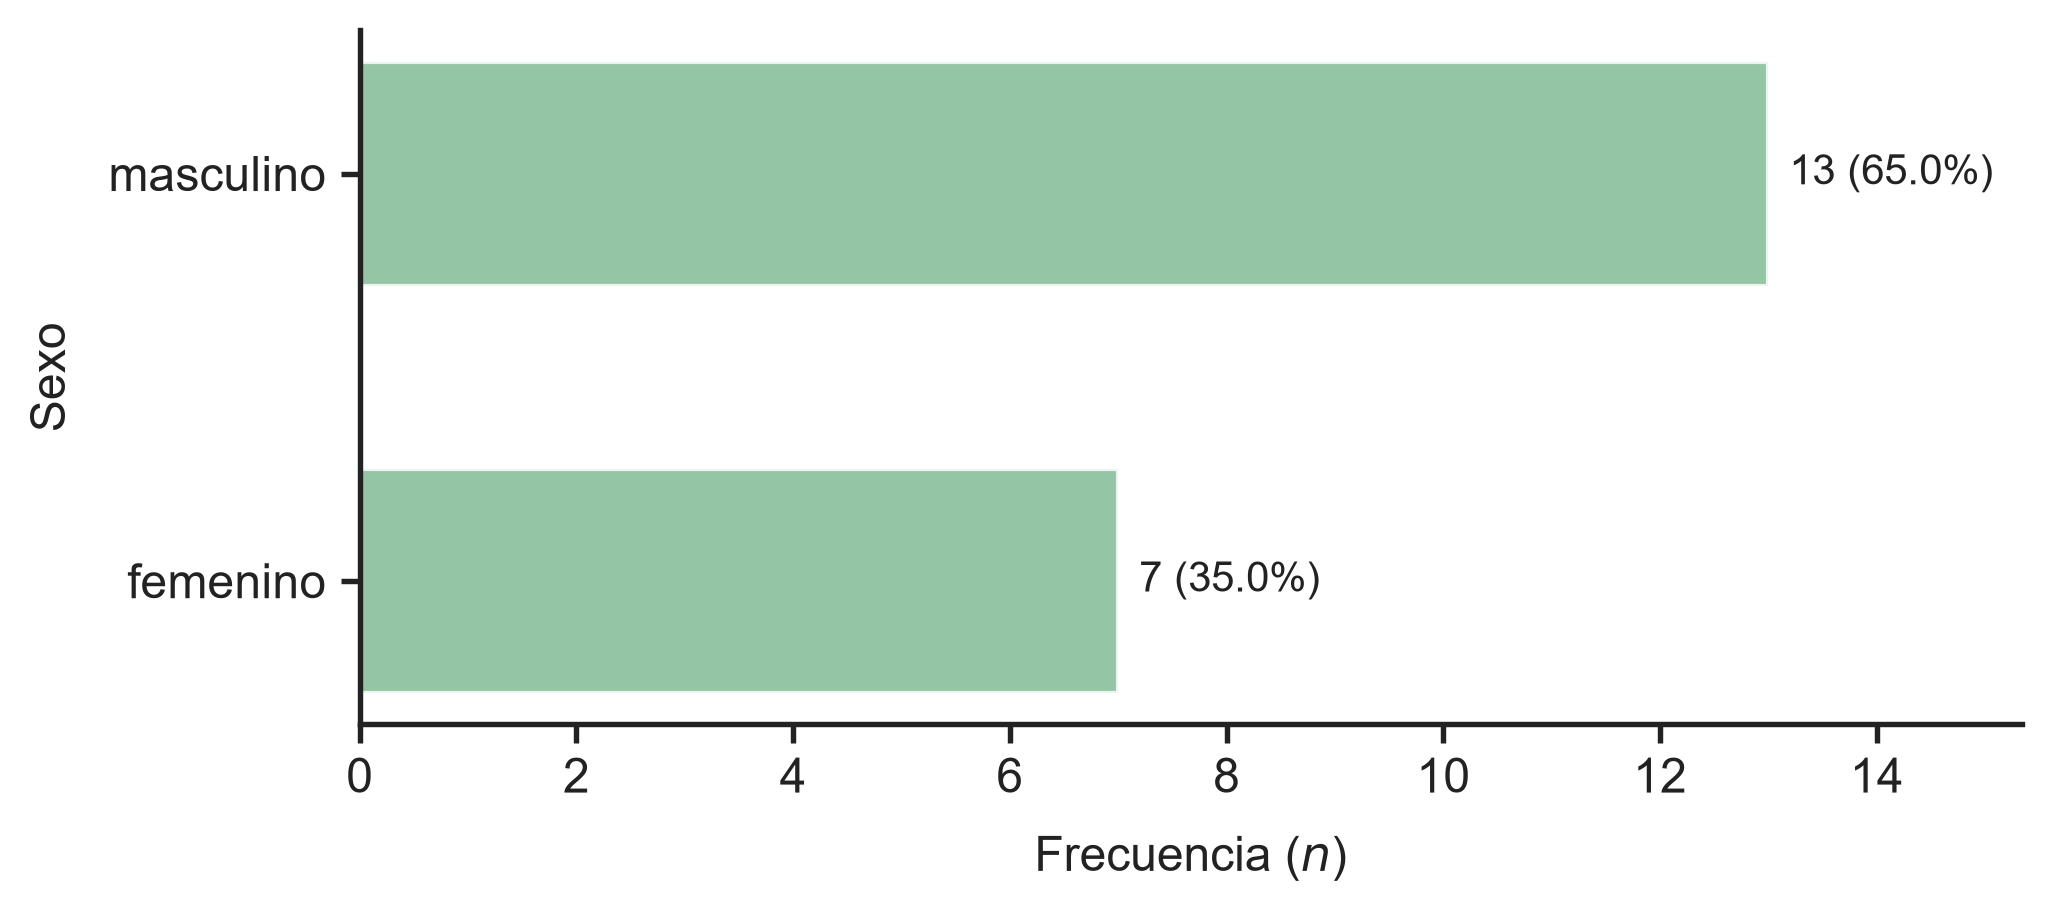

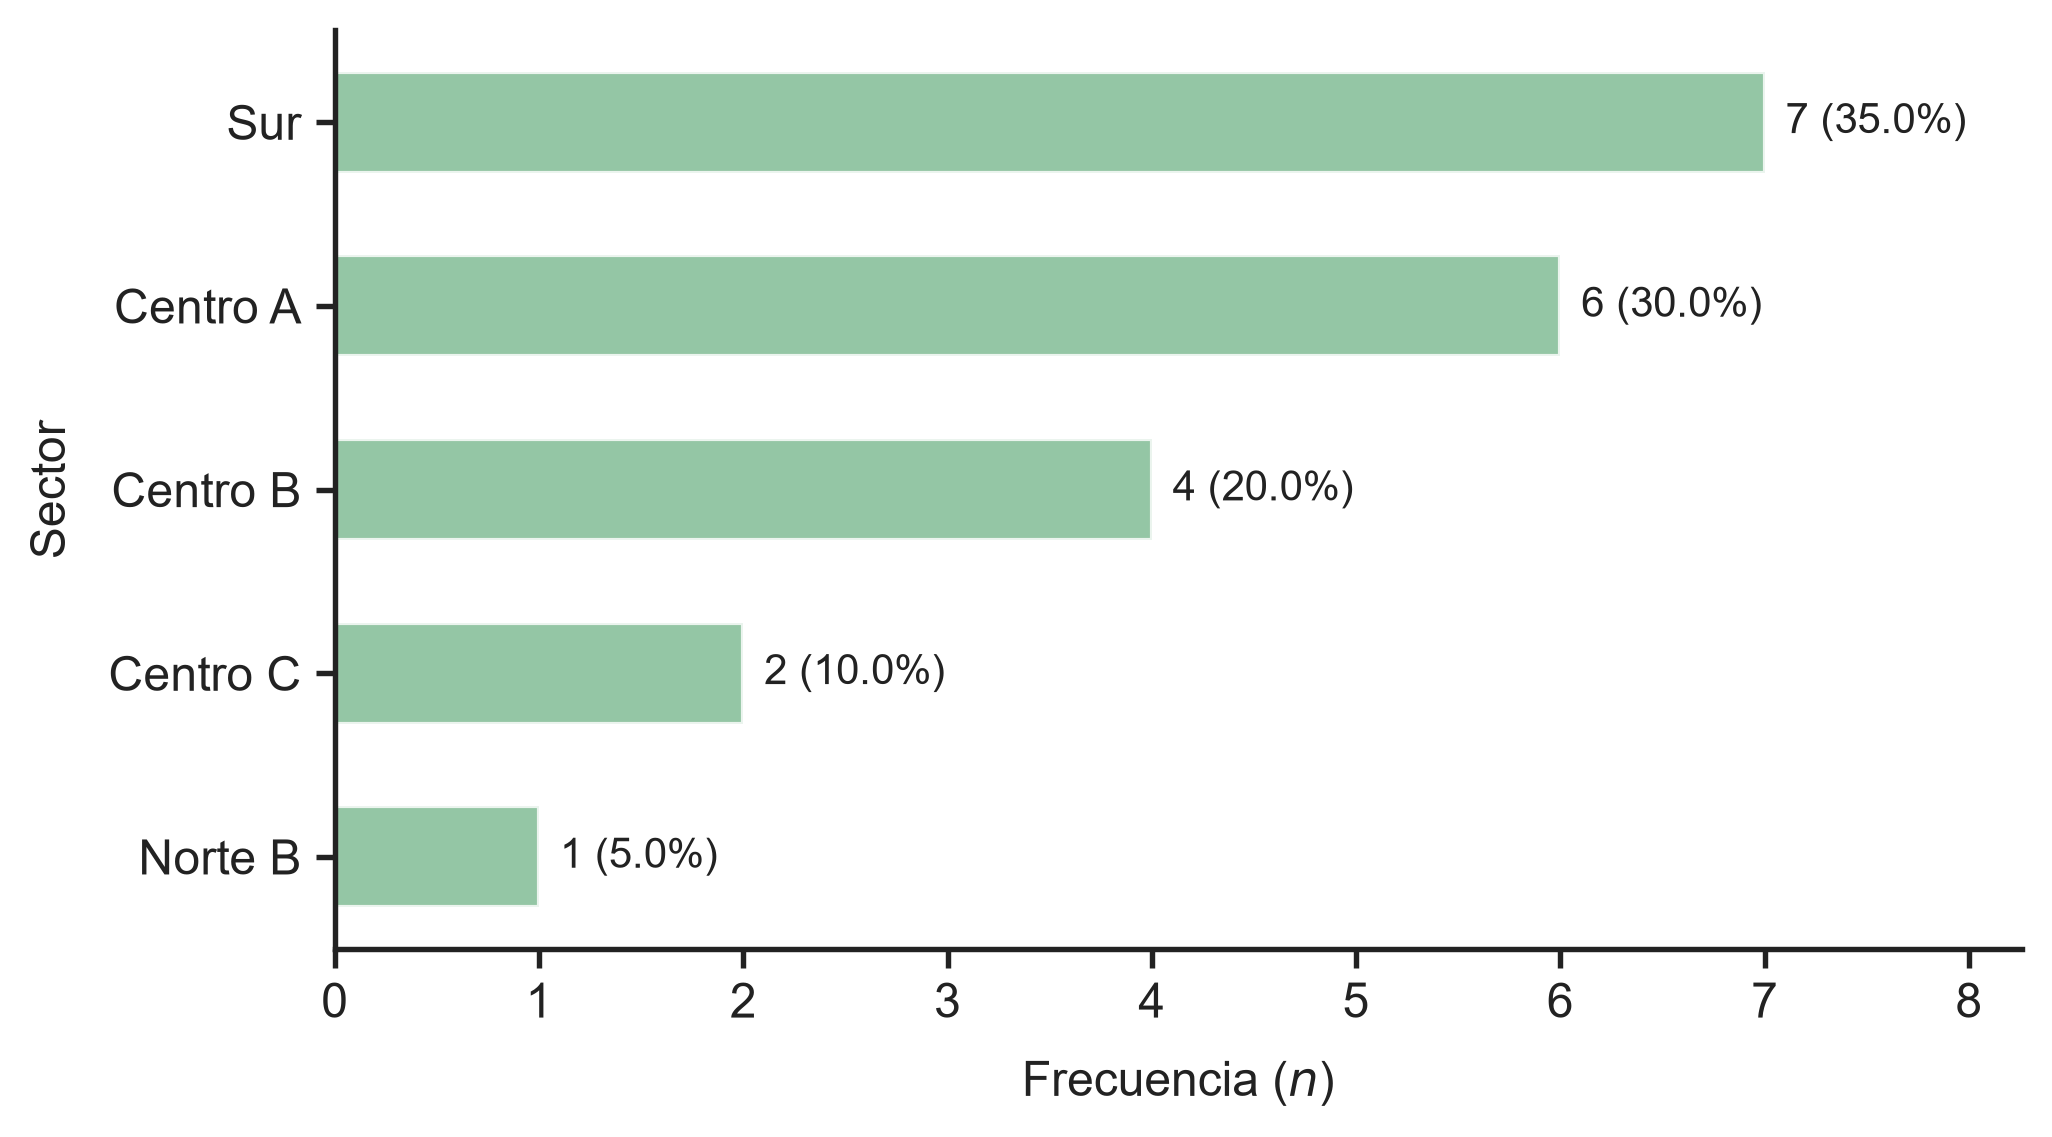

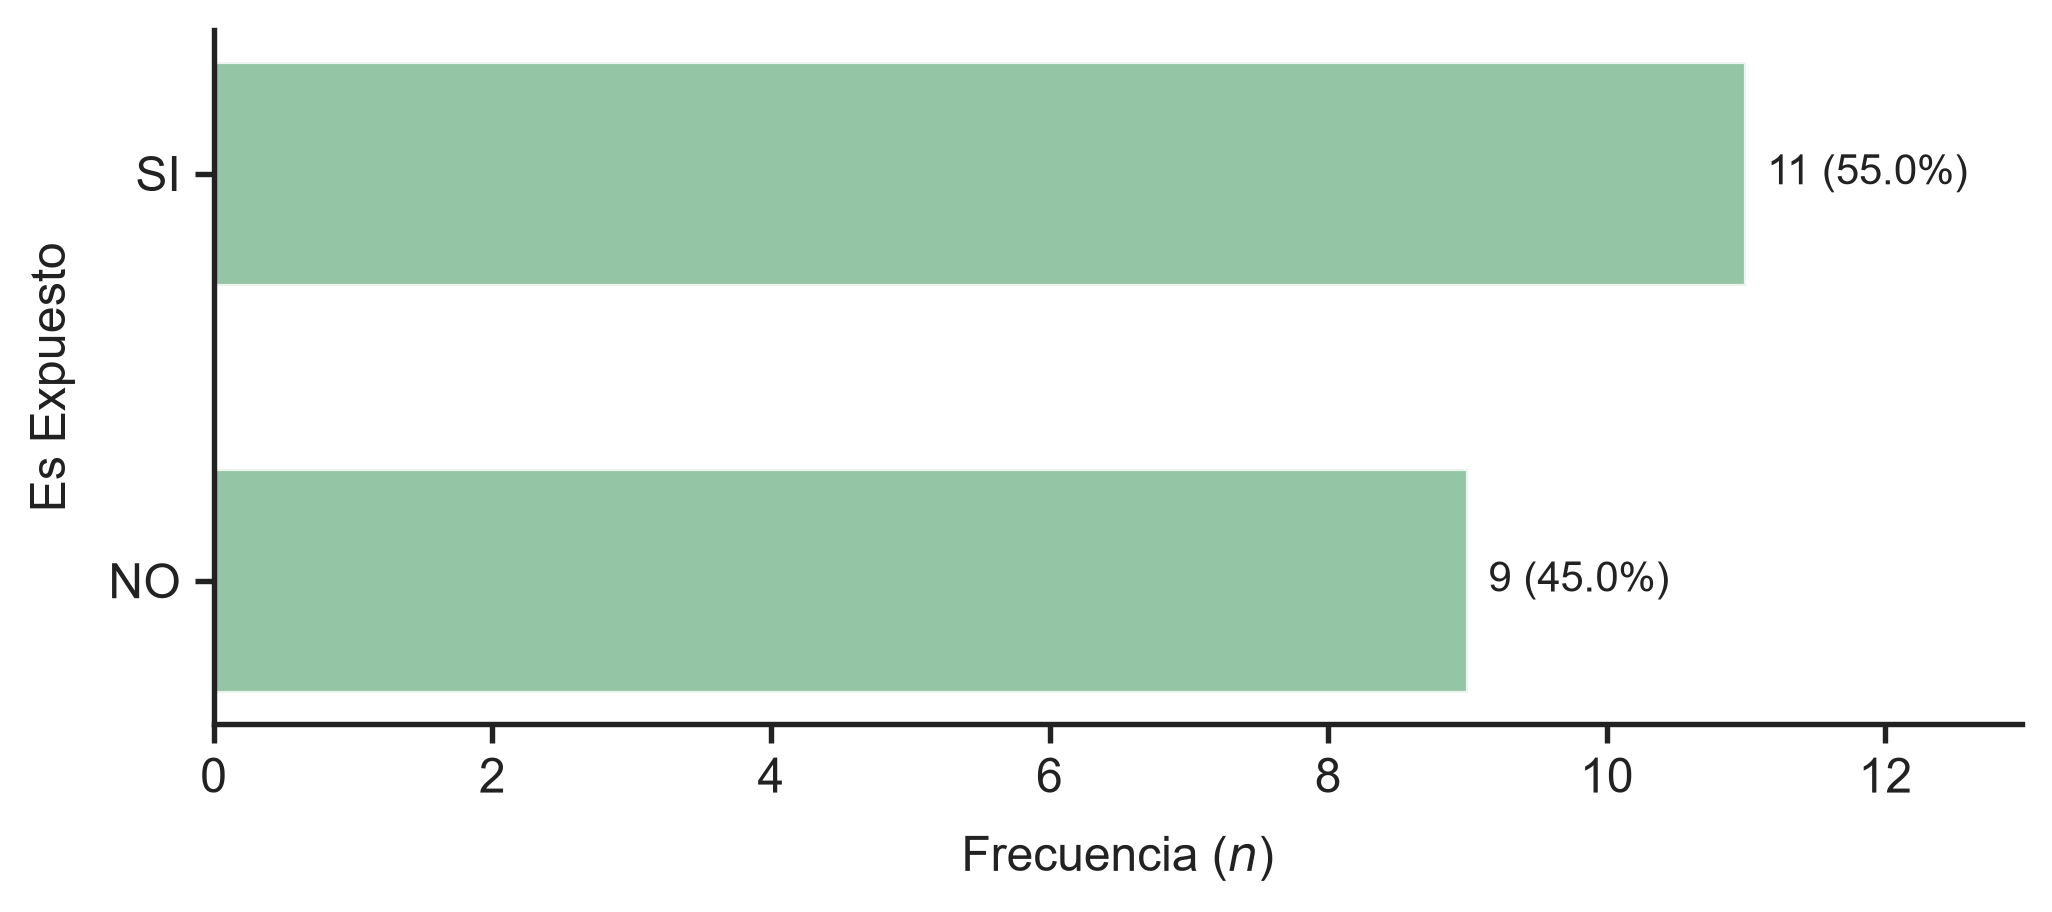

In [4]:
# Gráficos de barras para Sexo, Sector y Condición de Exposición
fig_sexo = uplots.plot_categorical("Sexo", orientation="horizontal", show_values=True)
fig_sexo;

fig_sector = uplots.plot_categorical("Sector", orientation="horizontal", show_values=True)
fig_sector;

fig_exp = uplots.plot_categorical("Es_Expuesto", orientation="horizontal", show_values=True)
fig_exp;

--- 
## 3. Resumen de Variables Numéricas Continuas y Pruebas de Normalidad

Siguiendo las recomendaciones del **ICMJE** y la declaración **STROBE**:
- Para variables con distribución aproximadamente simétrica se reporta la **Media (DE)**.
- Para variables con distribución asimétrica o sesgada se reporta la **Mediana [RIQ]** (Rango Intercuartílico $[Q_1 - Q_3]$).

El método `numerical_summary()` evalúa la simetría mediante el coeficiente de **Asimetría** ($\gamma_1$), la **Curtosis** ($\gamma_2$) y la prueba de normalidad de **Shapiro-Wilk** ($W, p$), resaltando en negrita la medida de tendencia central recomendada.


In [5]:
# Resumen descriptivo de variables continuas y diagnóstico de normalidad
report_num = tables.numerical_summary()
report_num

Variable,Distribución,N,Media (DE),Mediana [RIQ],Mín - Máx,Asimetría,Curtosis,Shapiro-Wilk (p-val),Anderson-Darling (A²)
Edad,Sesgada,20,7.40 (1.23),7.00 [6.75 - 8.25],5.00 - 9.00,-0.111,-1.023,0.0511,0.742*
Peso (kg),Simétrica,20,26.10 (7.14),24.50 [20.75 - 31.25],15.00 - 41.00,+0.521,-0.701,0.3336,0.422
Altura (cm),Simétrica,20,128.00 (8.93),129.00 [120.50 - 134.25],108.00 - 141.00,-0.427,-0.548,0.4547,0.325
Score de Riesgo,Sesgada,20,3.25 (1.68),4.00 [1.75 - 5.00],1.00 - 5.00,-0.268,-1.599,0.0013,1.417*


### Diagnóstico Gráfico de Distribución: Gráficos Q-Q y Boxplot-Histogramas Integrados
Visualizamos la concordancia con la distribución normal teórica y la forma de la densidad empírica para la variable de riesgo continuo (`Score_Riesgo`) y la edad de los participantes.


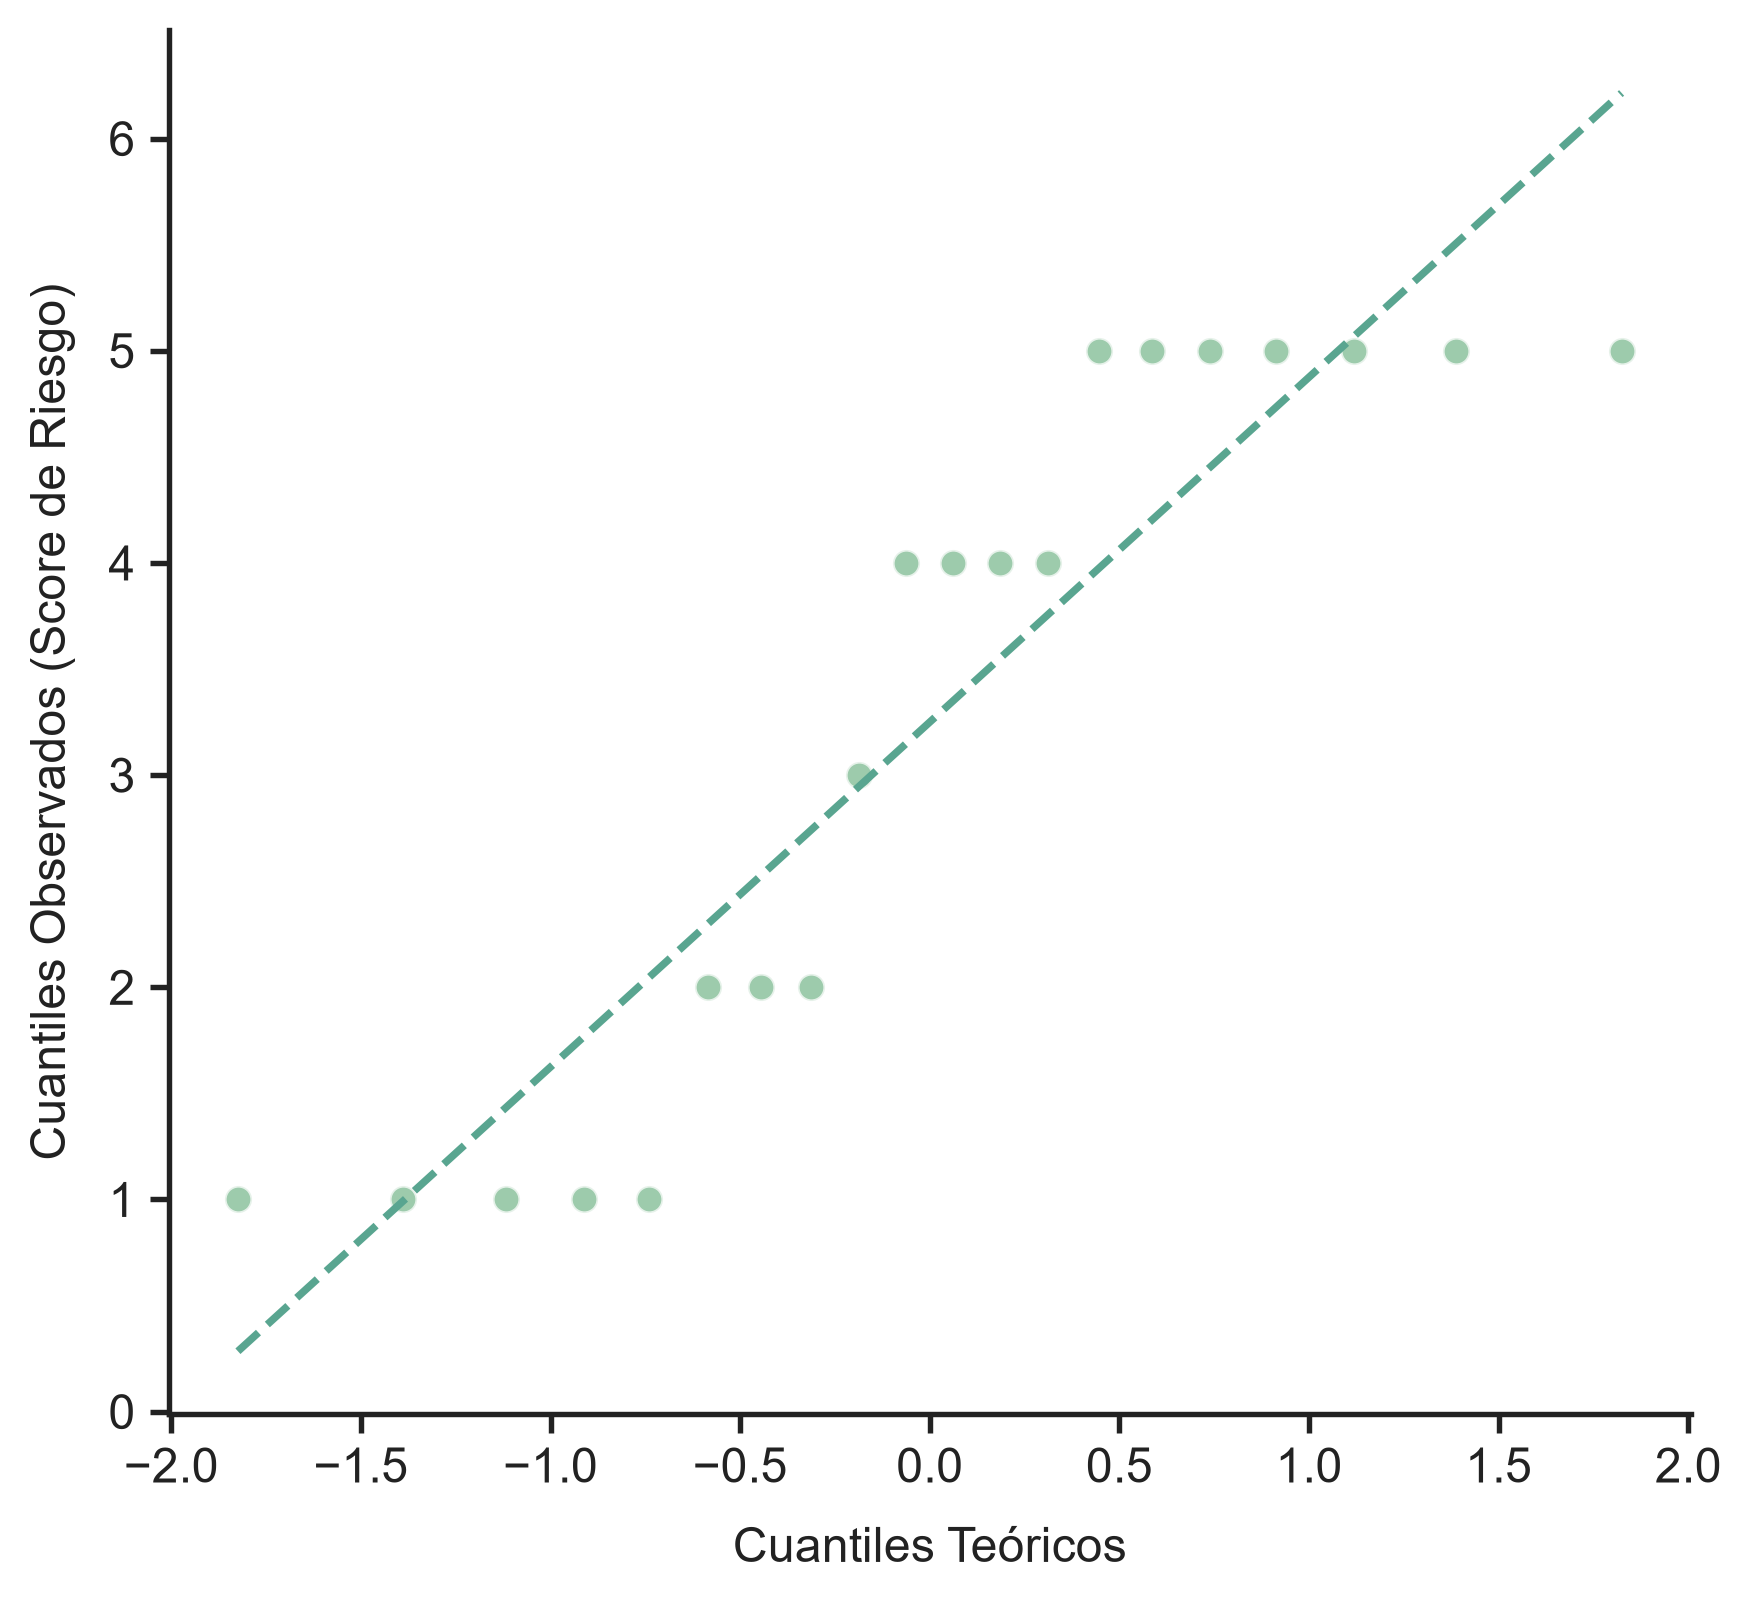

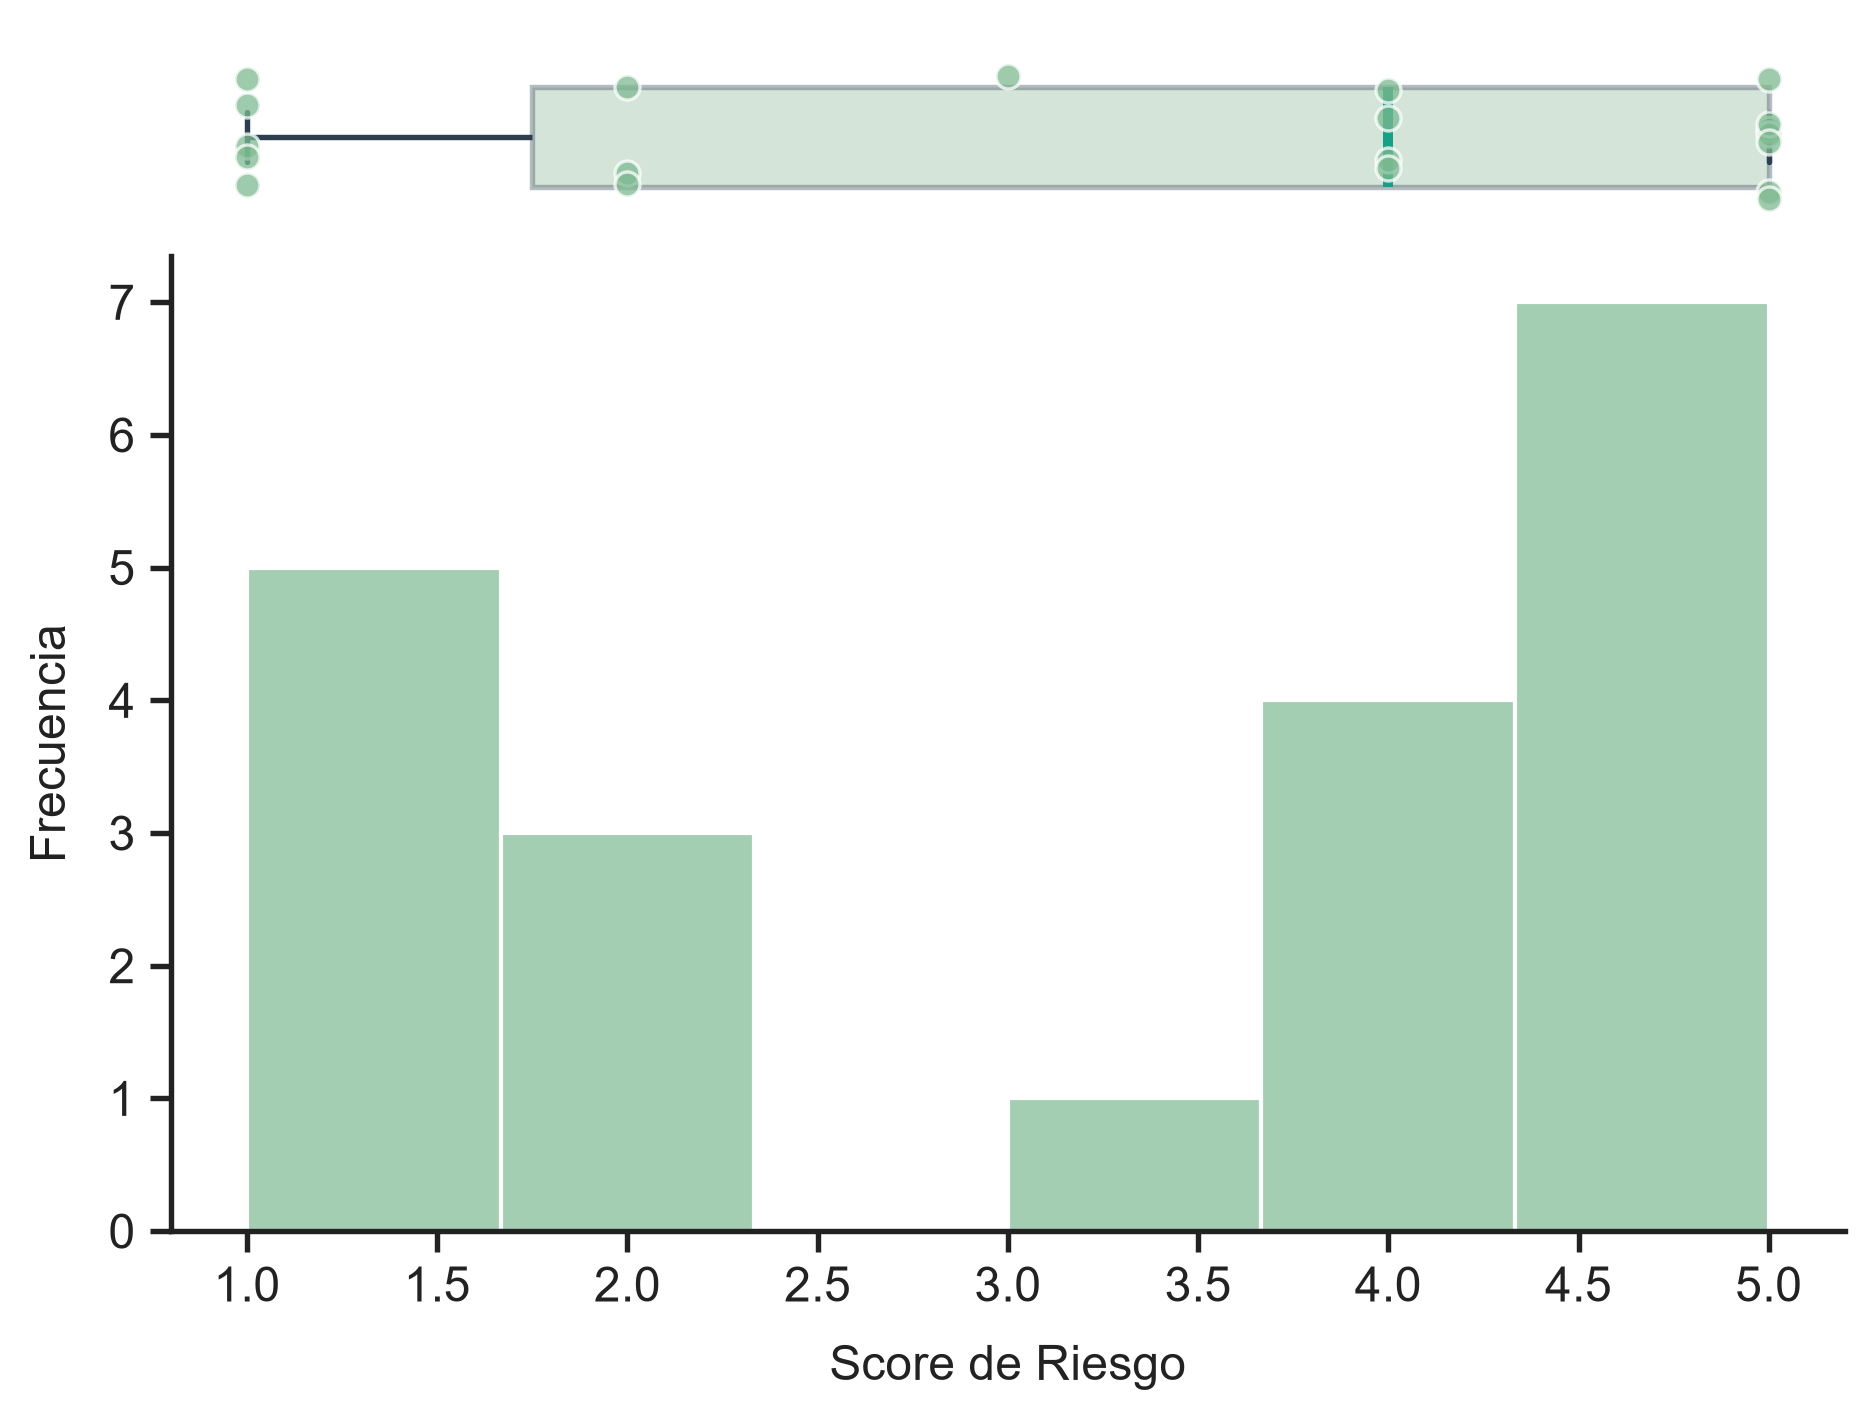

In [6]:
# Gráfico Q-Q de normalidad para Score de Riesgo
fig_qq_score = uplots.plot_qq("Score_Riesgo")
fig_qq_score;

# Gráfico combinado de Boxplot e Histograma coordinados para Score_Riesgo y Edad
fig_bh_score = uplots.plot_box_histograms("Score_Riesgo", overlay_points=True)
fig_bh_score;

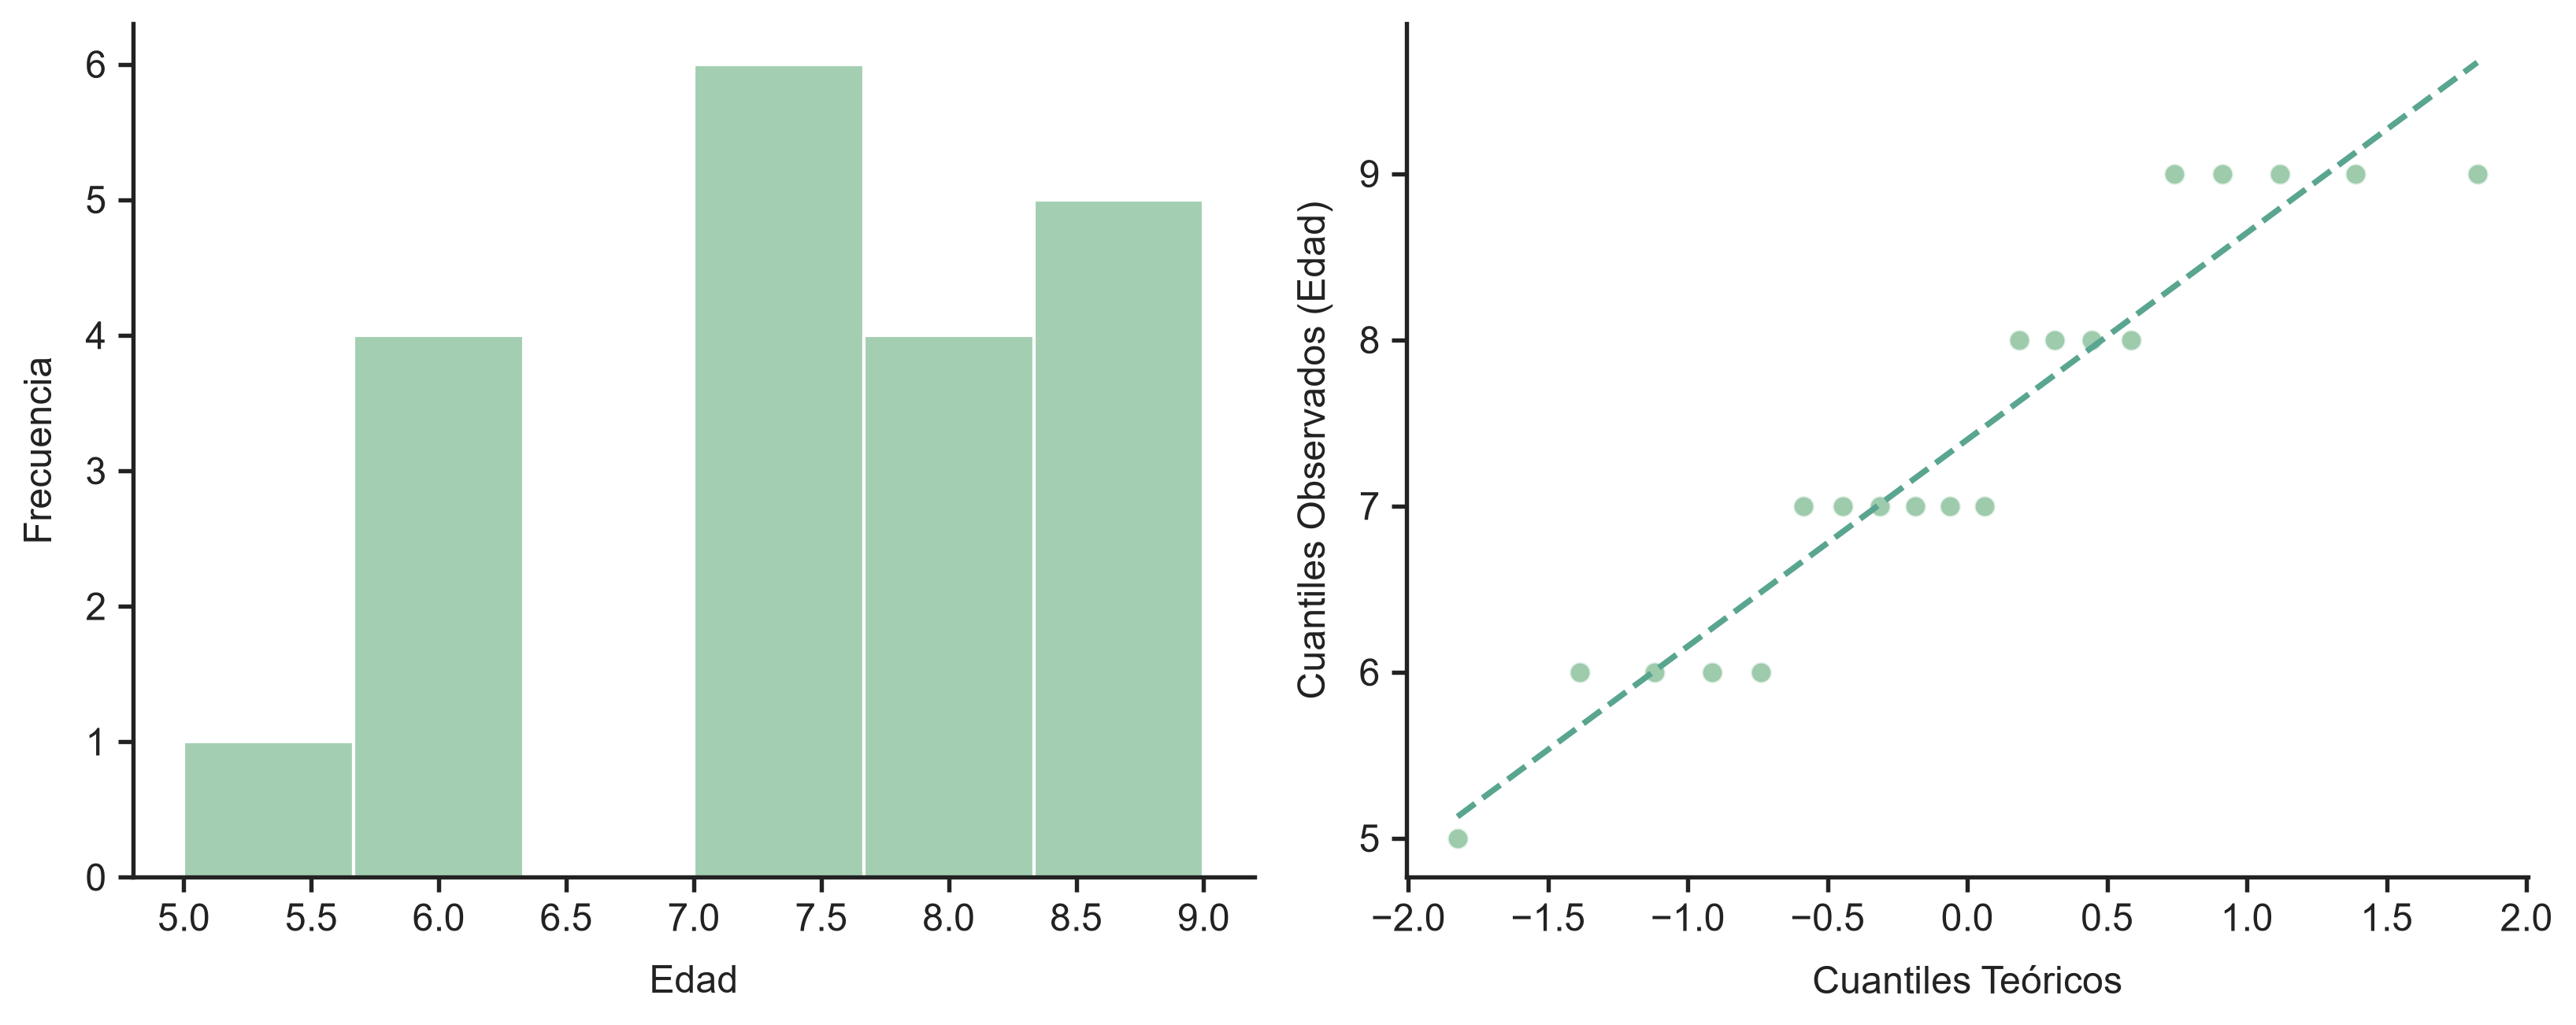

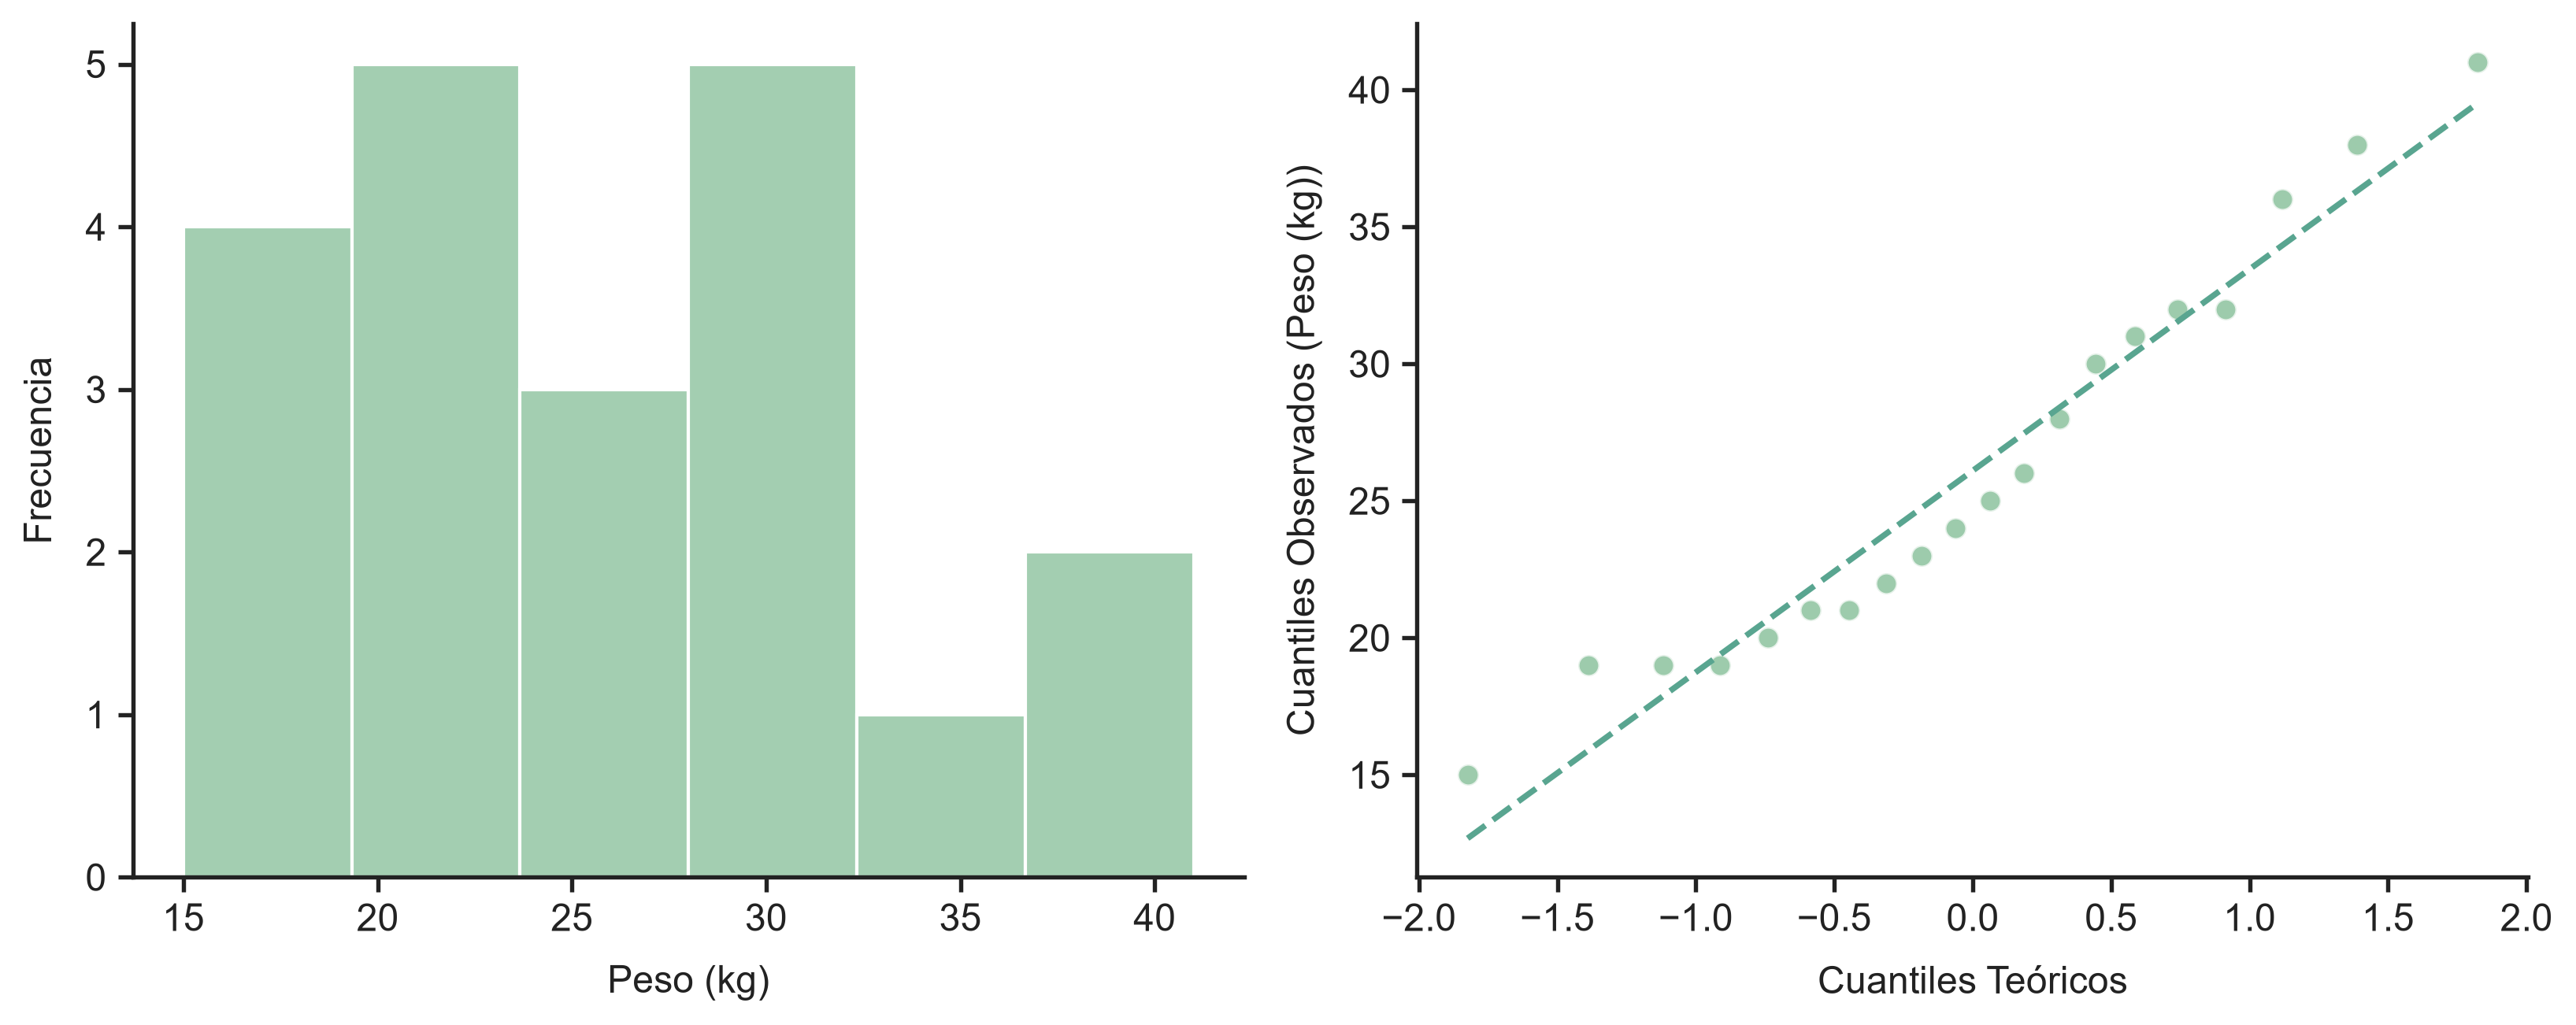

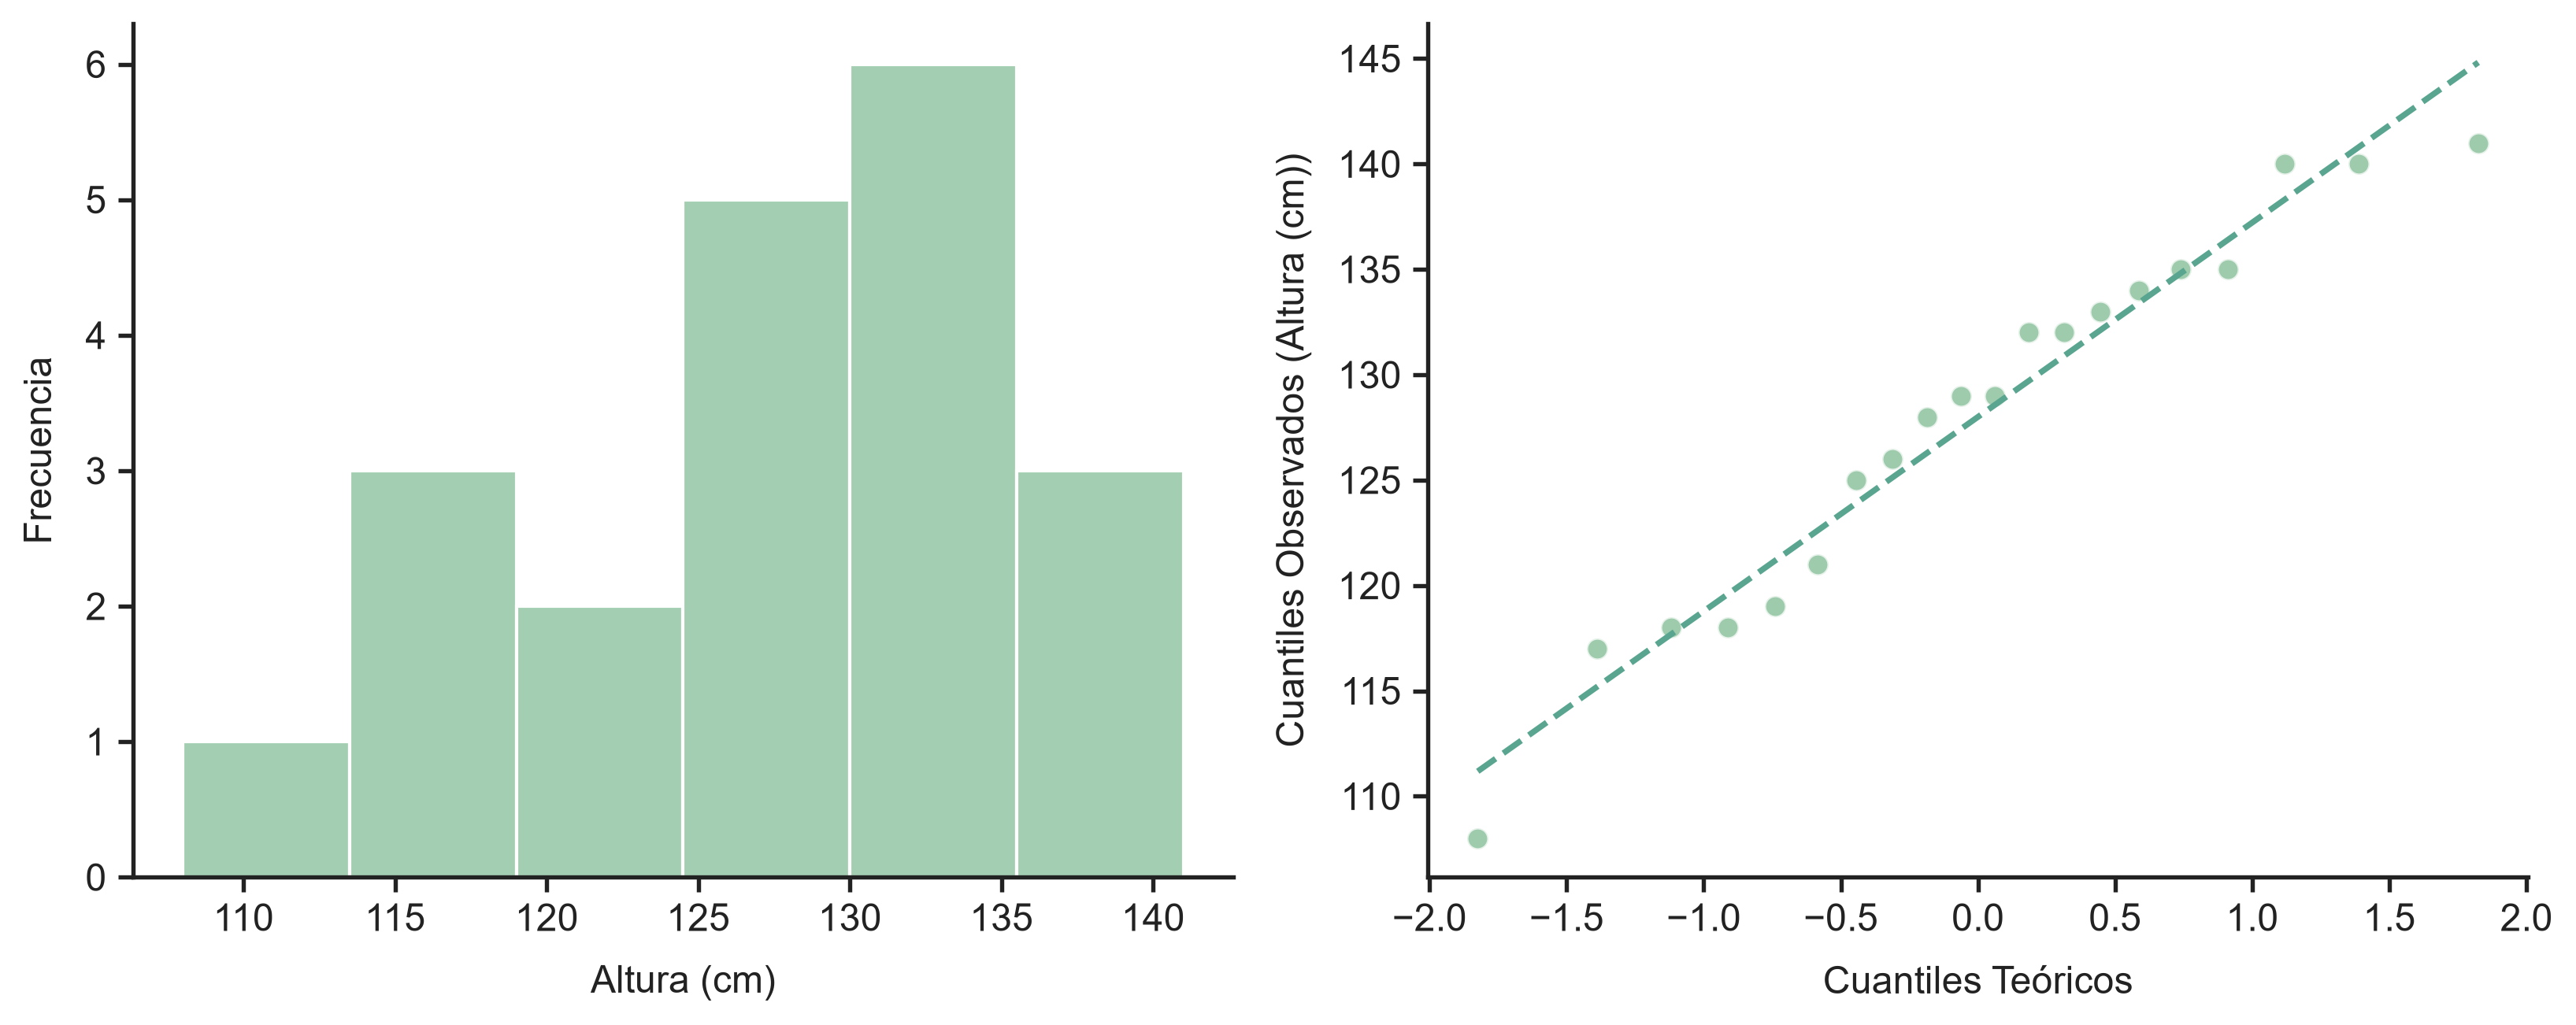

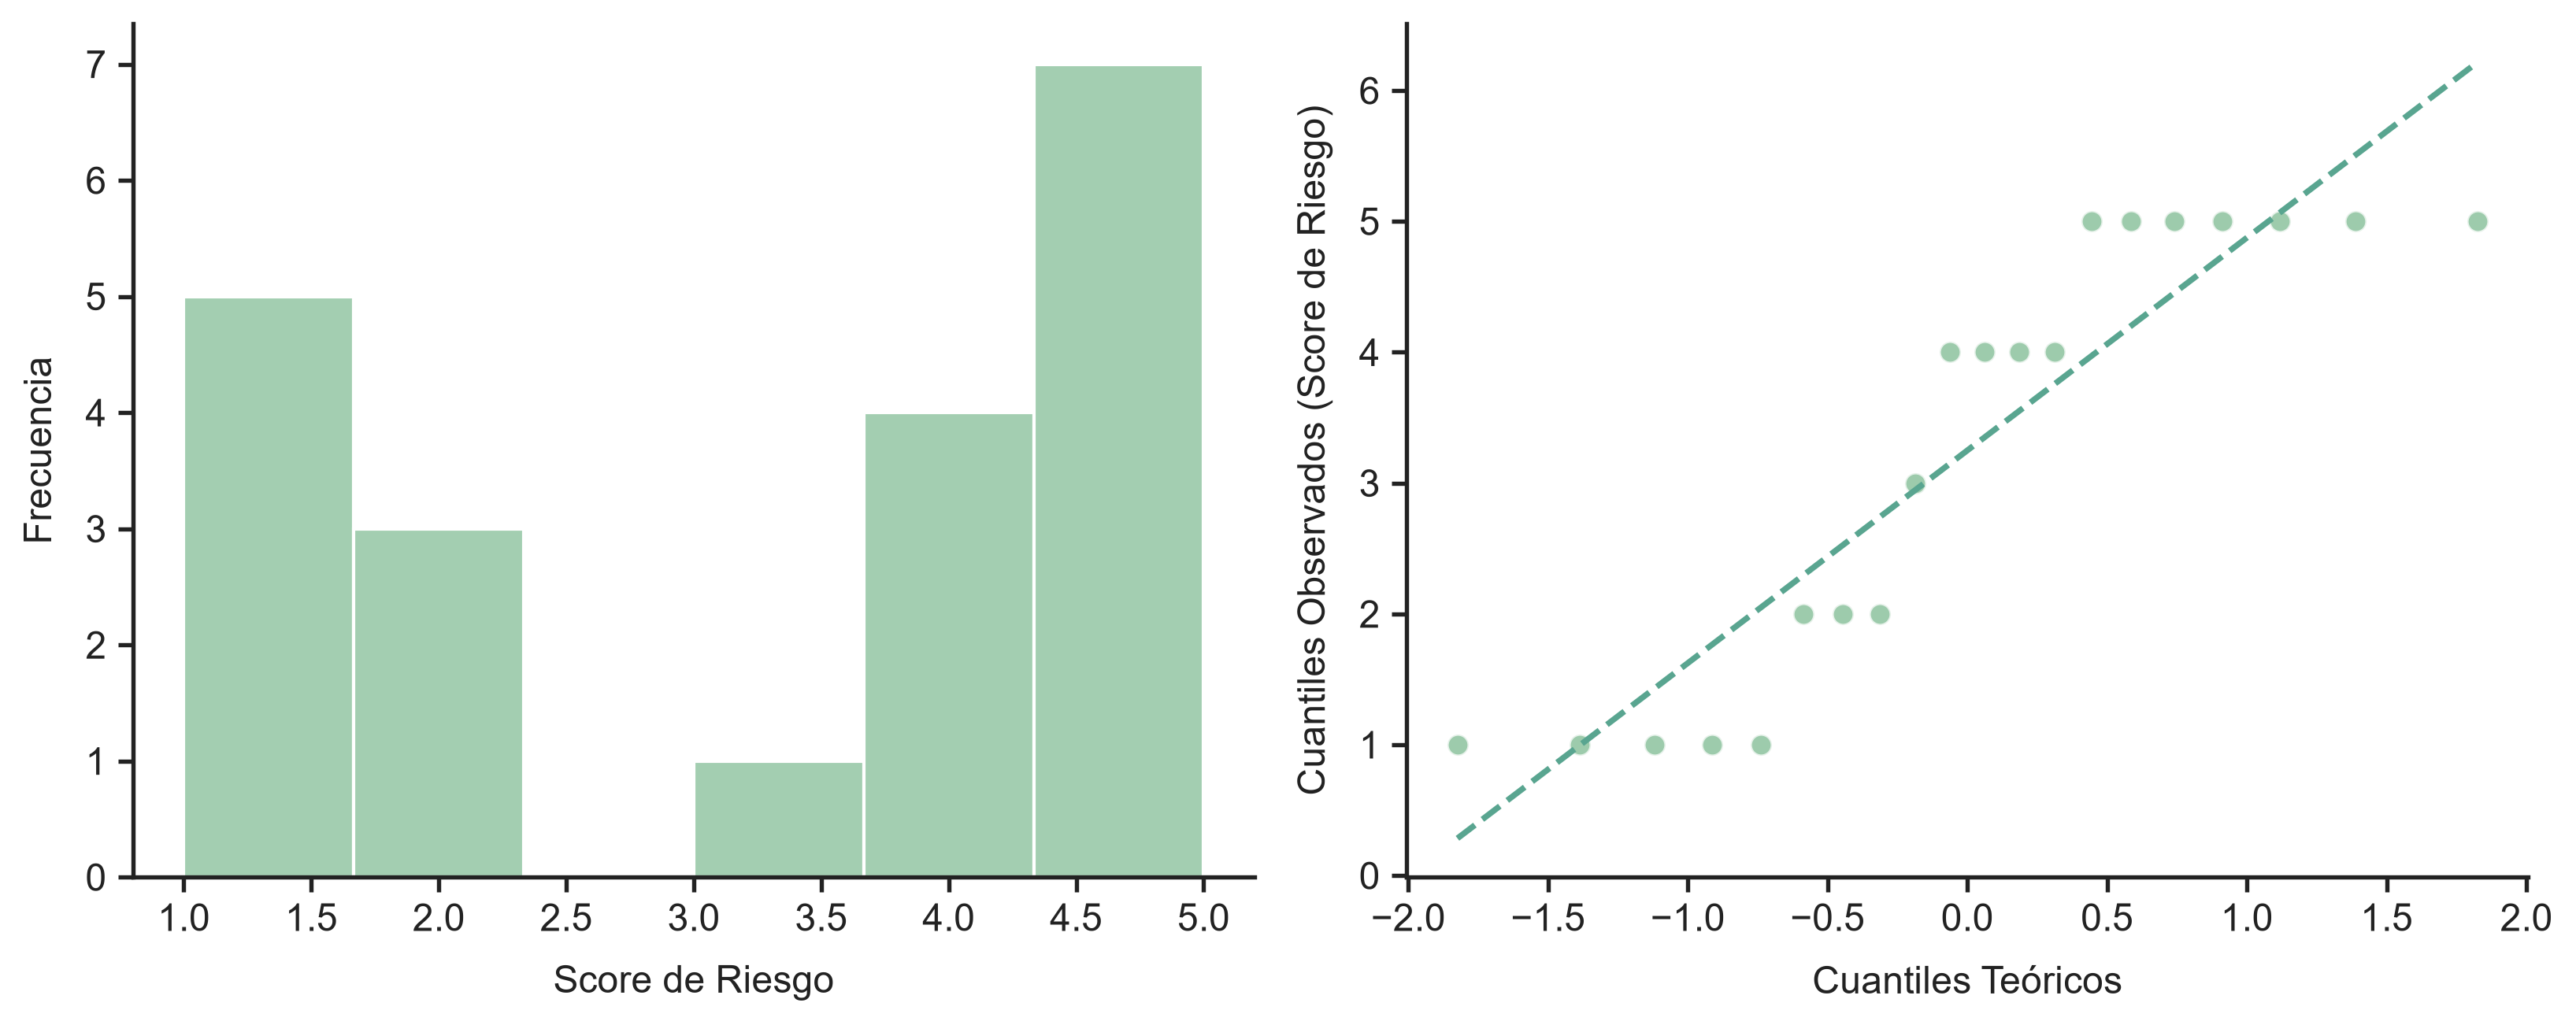

In [7]:
import matplotlib.pyplot as plt
cols = ["Edad", "Peso_kg", "Altura_cm", "Score_Riesgo"]
for col in cols:
    # 1. Crear la figura con 1 fila y 2 columnas
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(11, 4.5))
    
    # 2. Histograma en ax1
    uplots.plot_histograms(col, ax=ax1)
    
    # 3. Gráfico Q-Q en ax2
    uplots.plot_qq(col, ax=ax2)
    
    # 4. Ajustar espaciado y mostrar
    fig.tight_layout()
    plt.show()



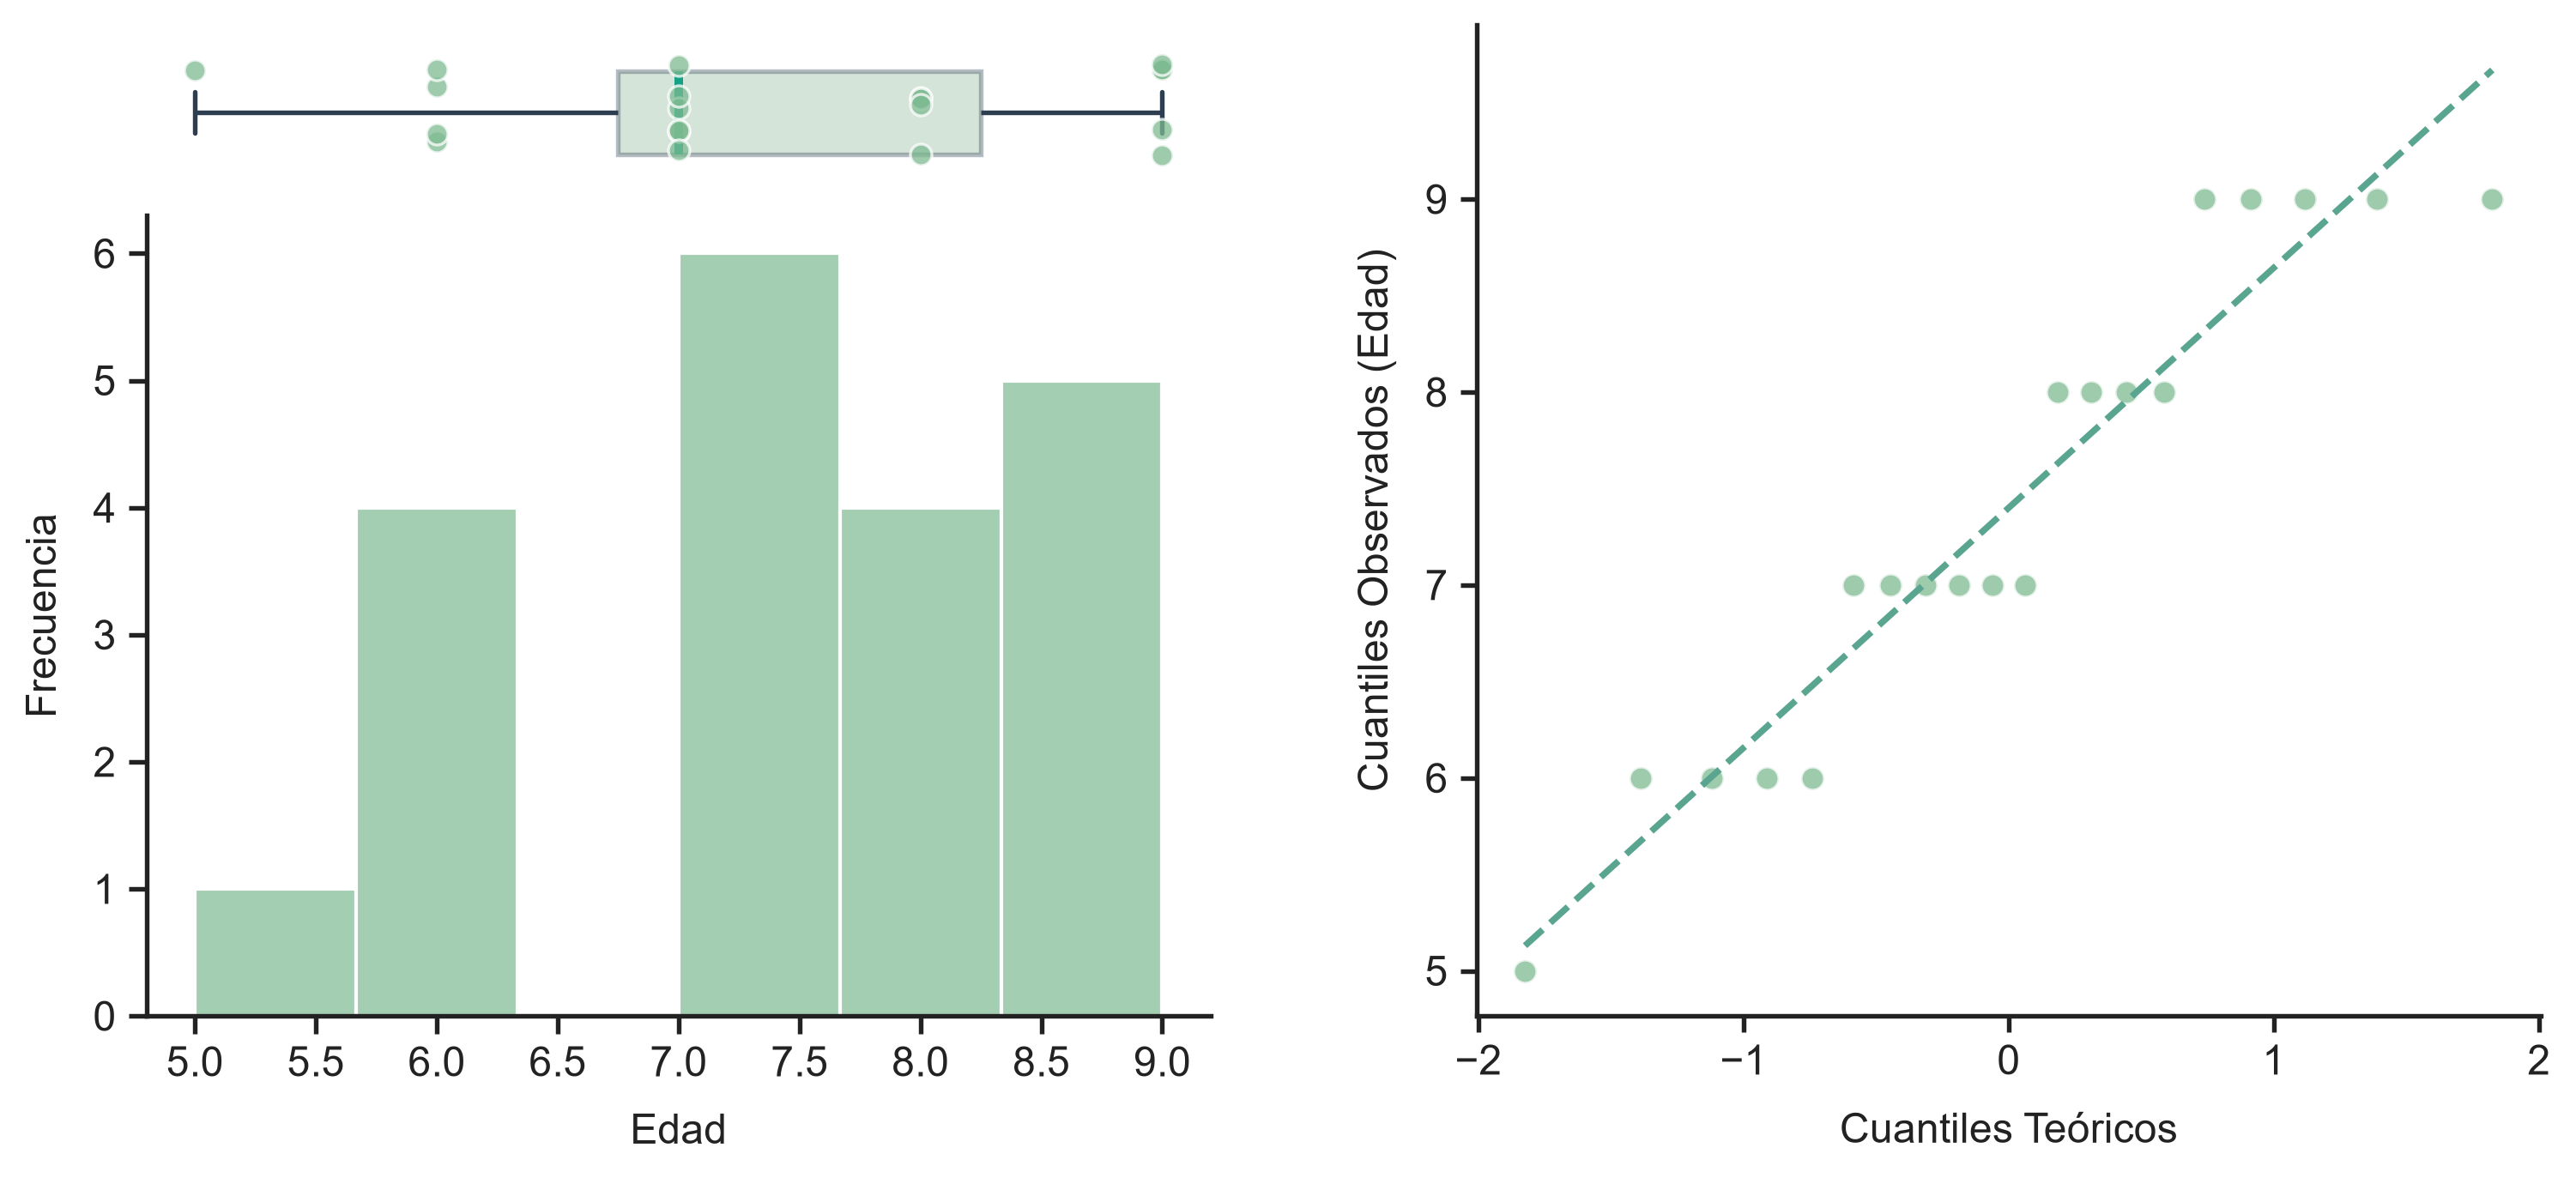

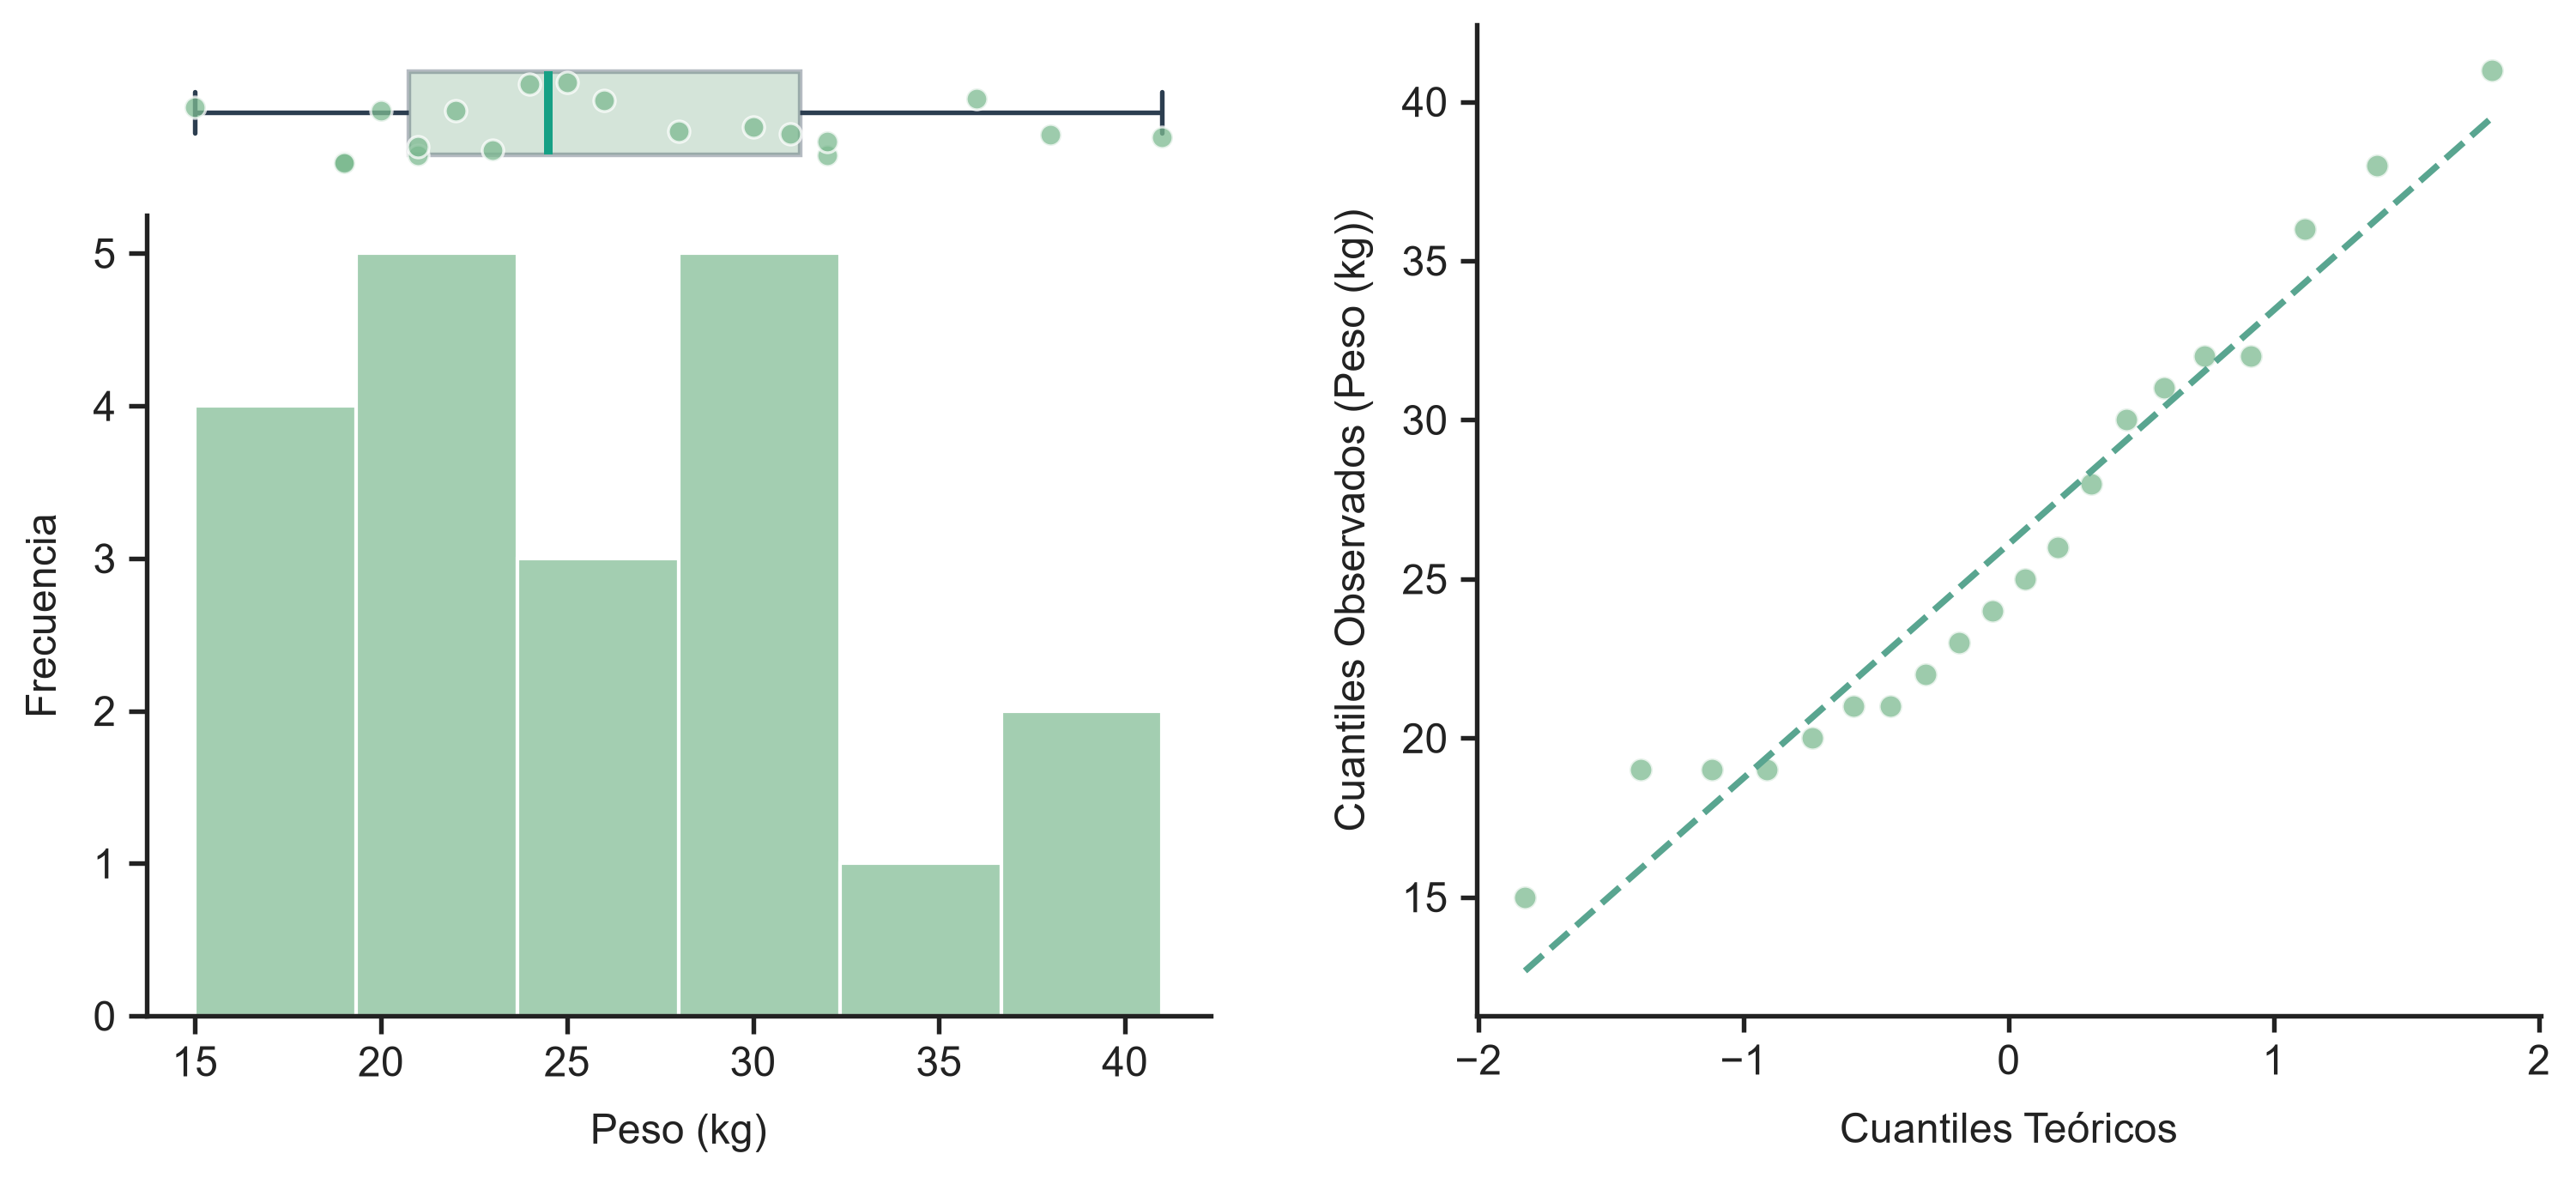

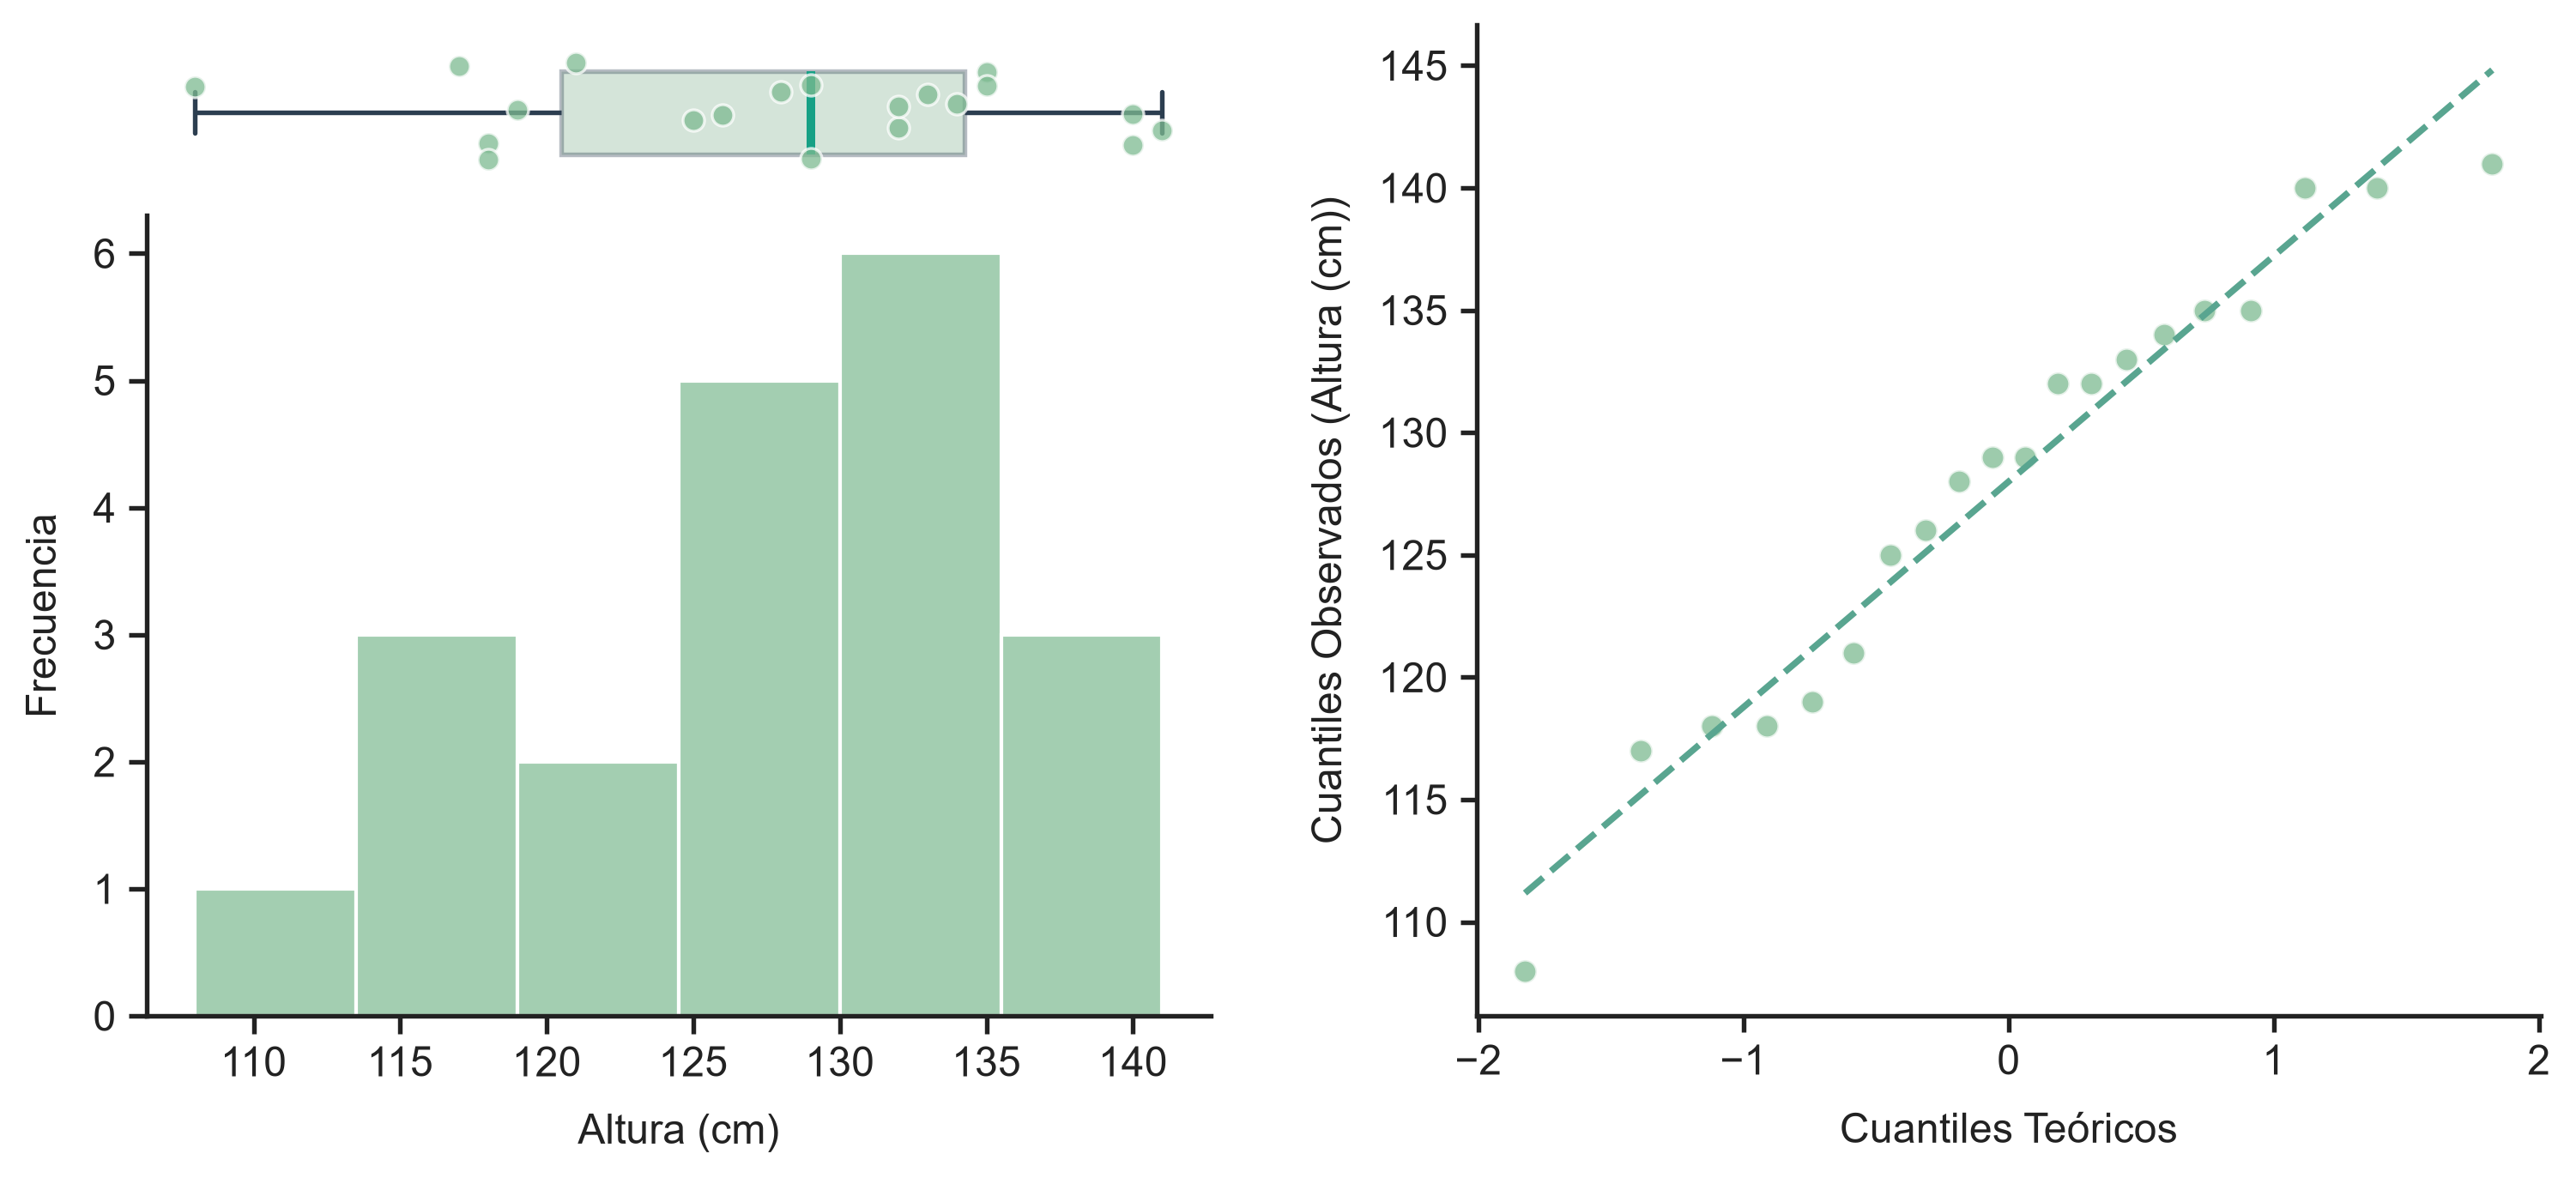

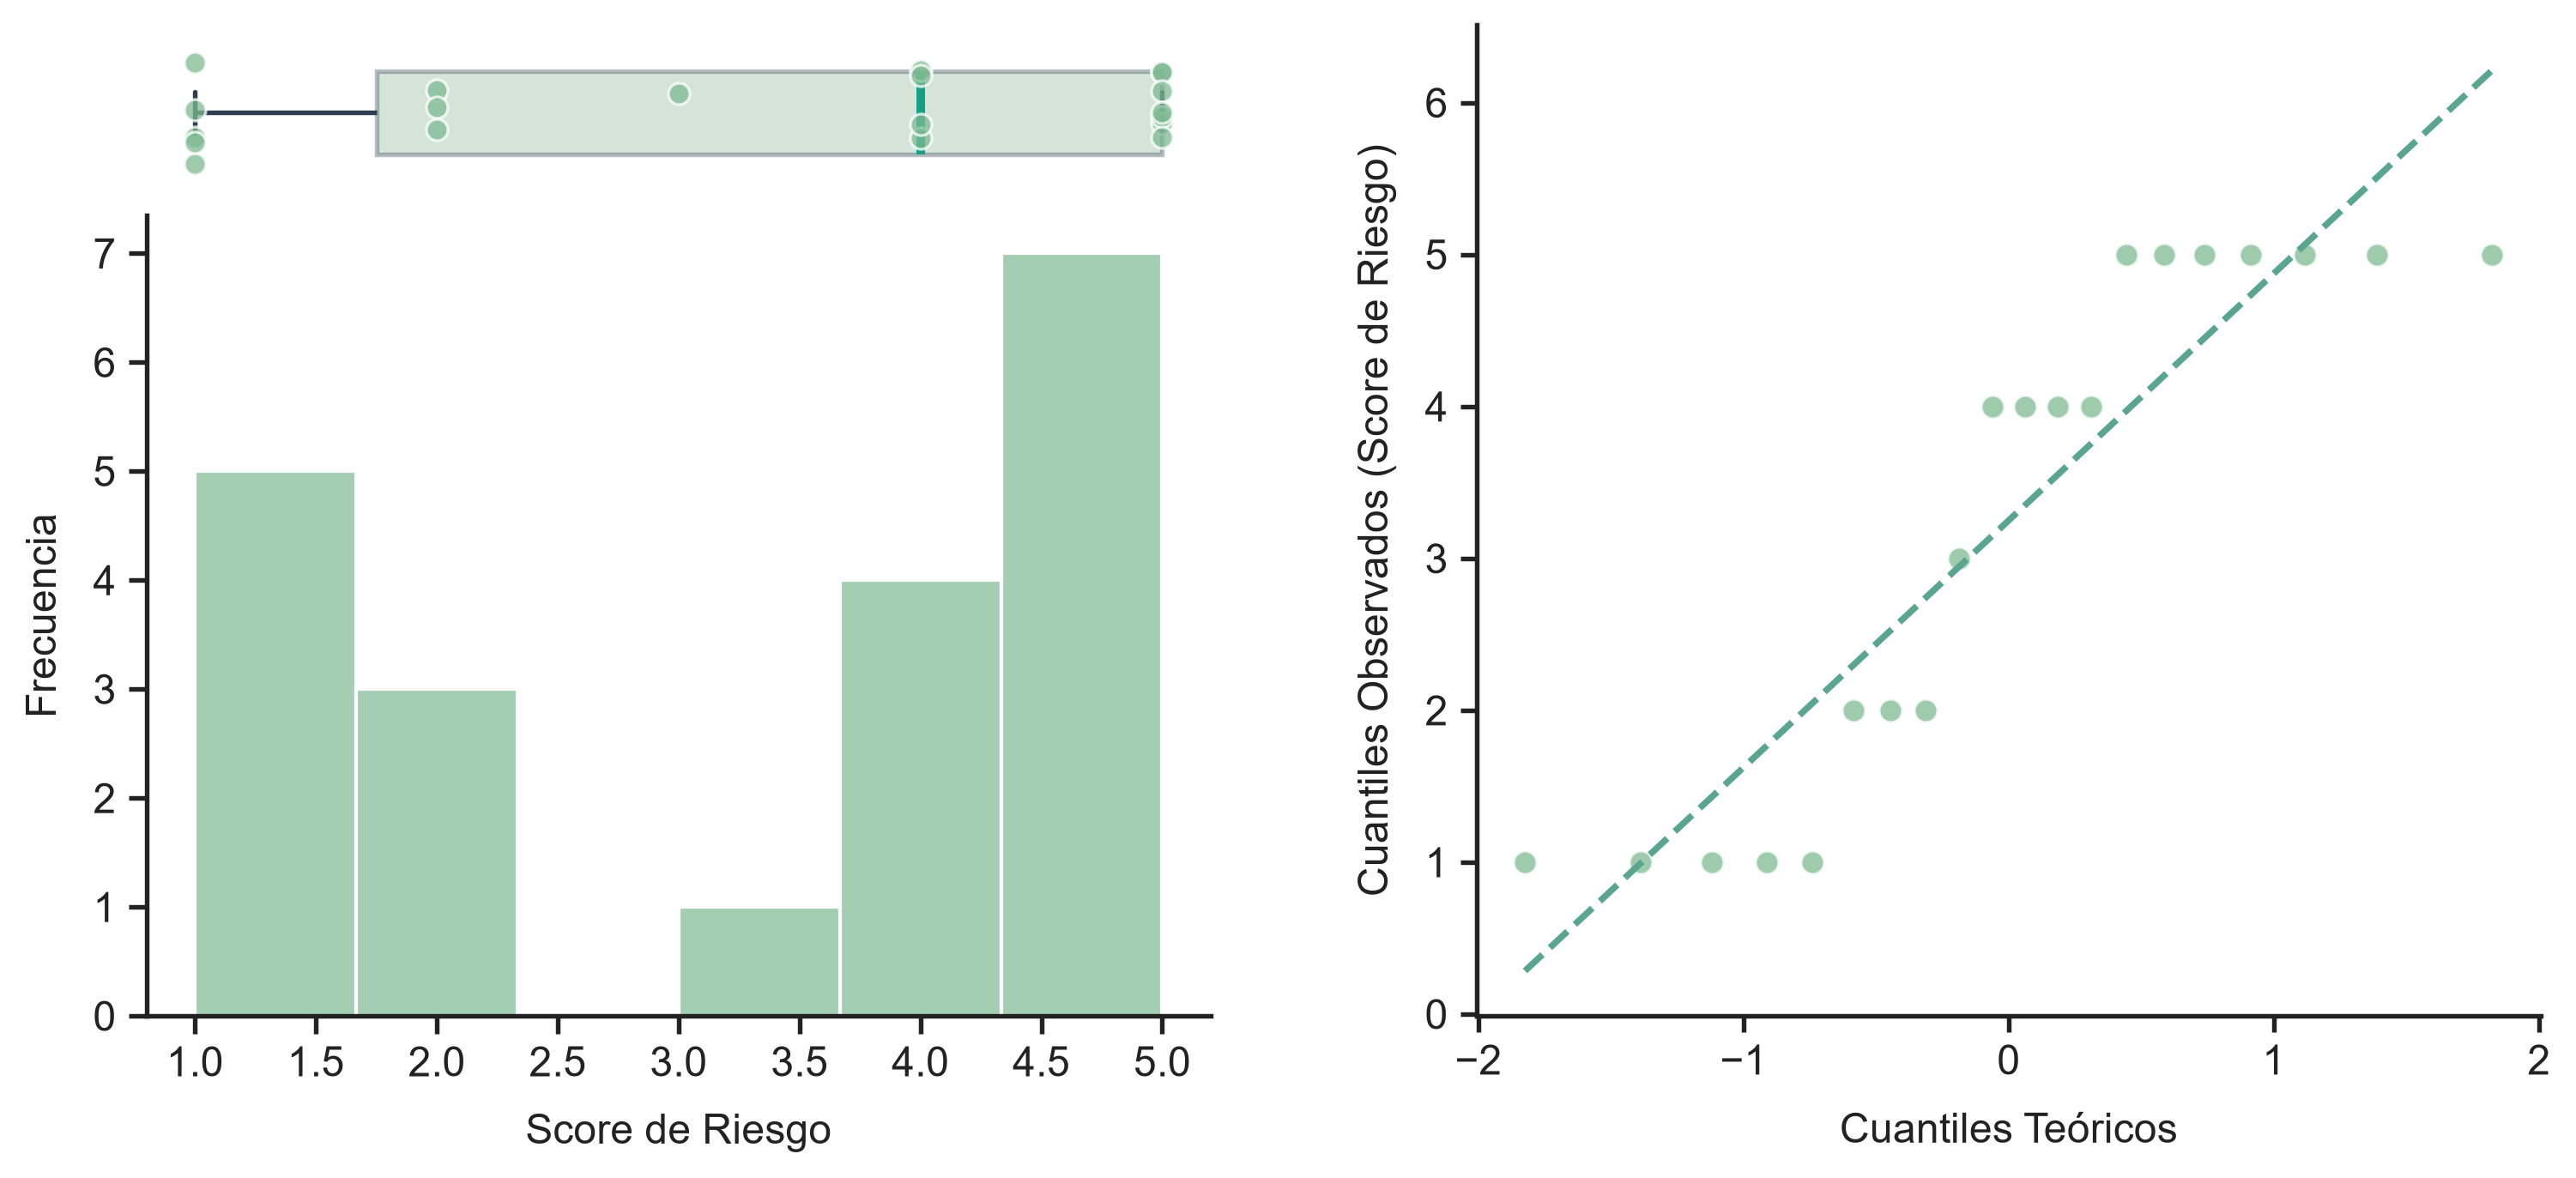

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

cols = ["Edad", "Peso_kg", "Altura_cm", "Score_Riesgo"]

for col in cols:
    fig = plt.figure(figsize=(12, 5))
    gs = gridspec.GridSpec(2, 2, height_ratios=[0.18, 0.82], width_ratios=[1, 1], hspace=0.03, wspace=0.25)
    
    # Panel Izquierdo: Boxplot (arriba) + Histograma (abajo)
    ax_box = fig.add_subplot(gs[0, 0])
    ax_hist = fig.add_subplot(gs[1, 0], sharex=ax_box)
    uplots.plot_box_histograms(col, axes=(ax_box, ax_hist), overlay_points=True)
    
    # Panel Derecho: Gráfico Q-Q ocupando ambas filas
    ax_qq = fig.add_subplot(gs[:, 1])
    uplots.plot_qq(col, ax=ax_qq)
    
    plt.show()


--- 
## 4. Análisis Toxicológico y Distribución de Metales Pesados en Sangre

Para las concentraciones de **Plomo** ($\text{Pb}$, $\mu\text{g/dL}$), **Mercurio** ($\text{Hg}$, $\mu\text{g/L}$) y **Cadmio** ($\text{Cd}$, $\mu\text{g/L}$), el método `metal_summary()` reporta:
1. **Límite de Detección (LOD)**: Porcentaje de muestras cuantificables ($\ge \text{LOD}$, con $\text{LOD}_{\text{Pb}} = 0.1$, $\text{LOD}_{\text{Hg}} = 0.1$, $\text{LOD}_{\text{Cd}} = 0.05$).
2. **Superación de Límites Sanitarios de Referencia**: Proporción de pacientes que igualan o superan los valores de referencia internacional en sangre (CDC Plomo $= 3.5\ \mu\text{g/dL}$; EPA/CDC Mercurio $= 5.0\ \mu\text{g/L}$; OMS/OSHA Cadmio $= 1.0\ \mu\text{g/L}$).
3. **Media Geométrica (GM) y Desviación Estándar Geométrica (GSD)**: Estimadores robustos bajo supuestos log-normales.
4. **Perfil de Percentiles Poblacionales**: $p_5, p_{10}, p_{25}, p_{50}$ (mediana), $p_{75}, p_{90}, p_{95}$.


In [9]:
# Análisis descriptivo toxicológico y distribución percentilar de metales pesados
report_metals = tables.metal_summary("Plomo")
report_metals

<UnivariateTableReport shape=(1, 13) title='Análisis Descriptivo de Metales Pesados en Sangre'>

### Visualización Toxicológica: Boxplots e Histogramas con Límites Permisibles
Graficamos la distribución empírica de cada metal superponiendo los límites permisibles de referencia toxicológica internacional y la dispersión individual de los pacientes mediante *stripplot*.


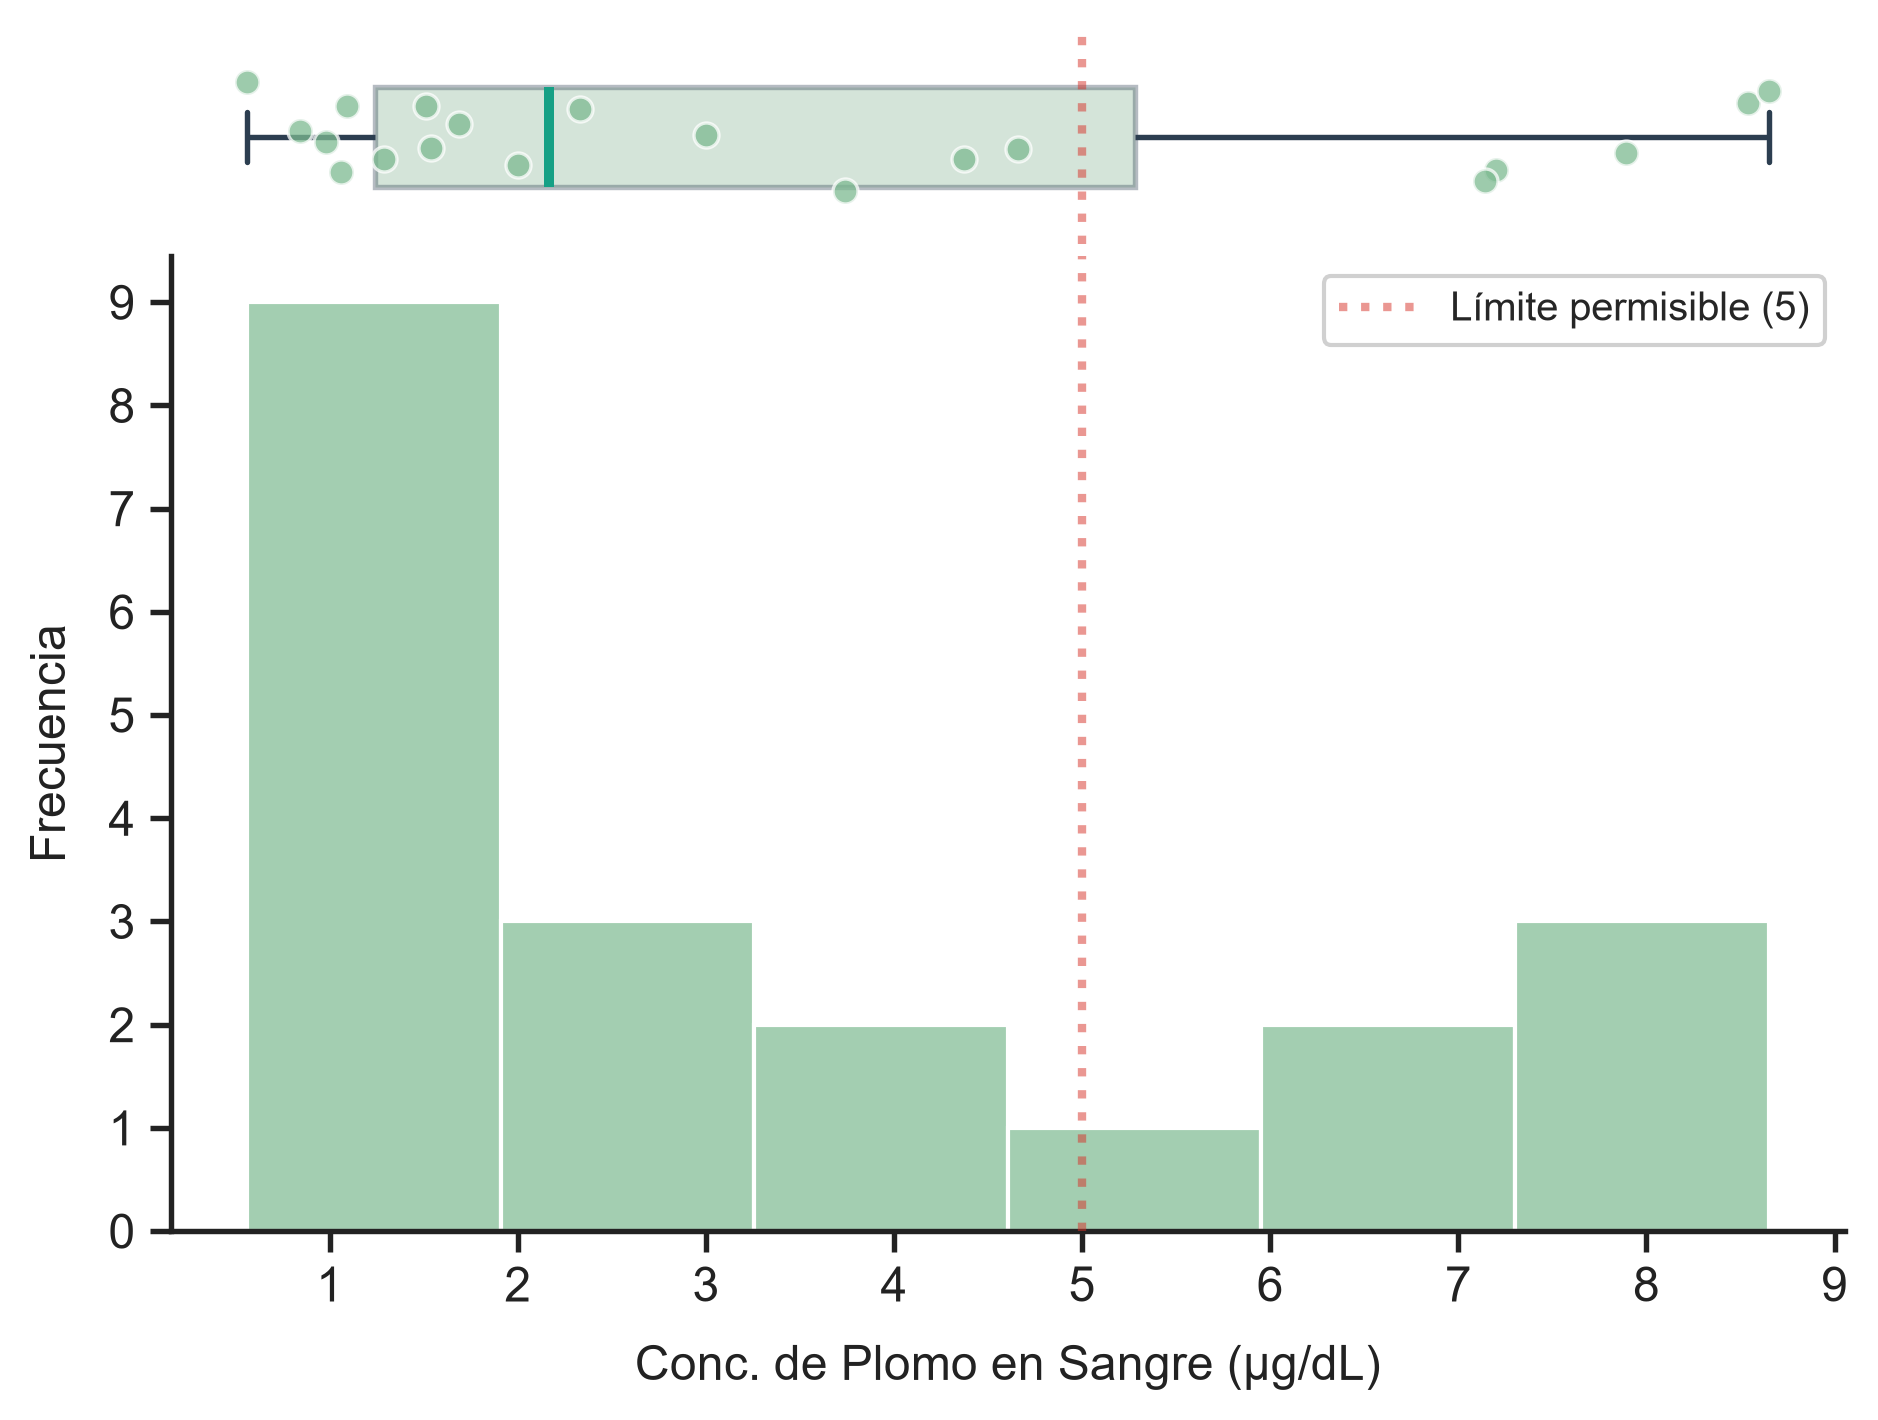

In [10]:
# Boxplot-Histogramas integrados con límites permisibles para Metales
fig_pb = uplots.plot_box_histograms("Plomo_ug_dL", show_limit=True, overlay_points=True)
fig_pb;

--- 
## 5. Evaluación Formal de la Transformación Logarítmica ($\ln$)

Las concentraciones biológicas de metales pesados típicamente presentan asimetría positiva (*right-skewed*). Para fundamentar el uso de modelos paramétricos bivariantes y multivariantes (ej. prueba $t$ de Welch y regresiones lineales sobre logaritmos), el método `log_transform_evaluation()` compara:
- **Asimetría y Curtosis**: Escala natural vs escala logarítmica natural ($\ln$).
- **Prueba de Shapiro-Wilk**: Estadístico $W$ y valor $p$ de normalidad en ambas escalas.
- **Conclusión Metodológica**: Recomendación estadística explícita.


In [11]:
# Evaluación comparativa de la transformación logarítmica de los metales
report_log = tables.log_transform_evaluation()
report_log

Metal,Transformación,Asimetría,Curtosis,Shapiro-Wilk (W),Shapiro-Wilk (p-val),¿Normal?,Conclusión
Conc. de Plomo en Sangre (µg/dL),Original,+0.755,-0.986,0.8338,0.0029,No,Base de comparación
,Logarítmico (ln),+0.078,-1.282,0.9336,0.1810,Sí,Recomendada
Conc. de Mercurio en Sangre (µg/L),Original,+0.955,-0.086,0.8857,0.0225,No,Base de comparación
,Logarítmico (ln),-0.336,-0.503,0.9726,0.8090,Sí,Recomendada
Conc. de Cadmio en Sangre (µg/L),Original,+0.428,-1.131,0.9189,0.0944,Sí,Base de comparación
,Logarítmico (ln),-0.697,-0.619,0.9131,0.0730,Sí,Original preferible


### Comparación Gráfica: Escala Natural vs Escala Logarítmica
Evaluamos visualmente el efecto de la escala logarítmica sobre la normalización y estabilización de la varianza en los biomarcadores.


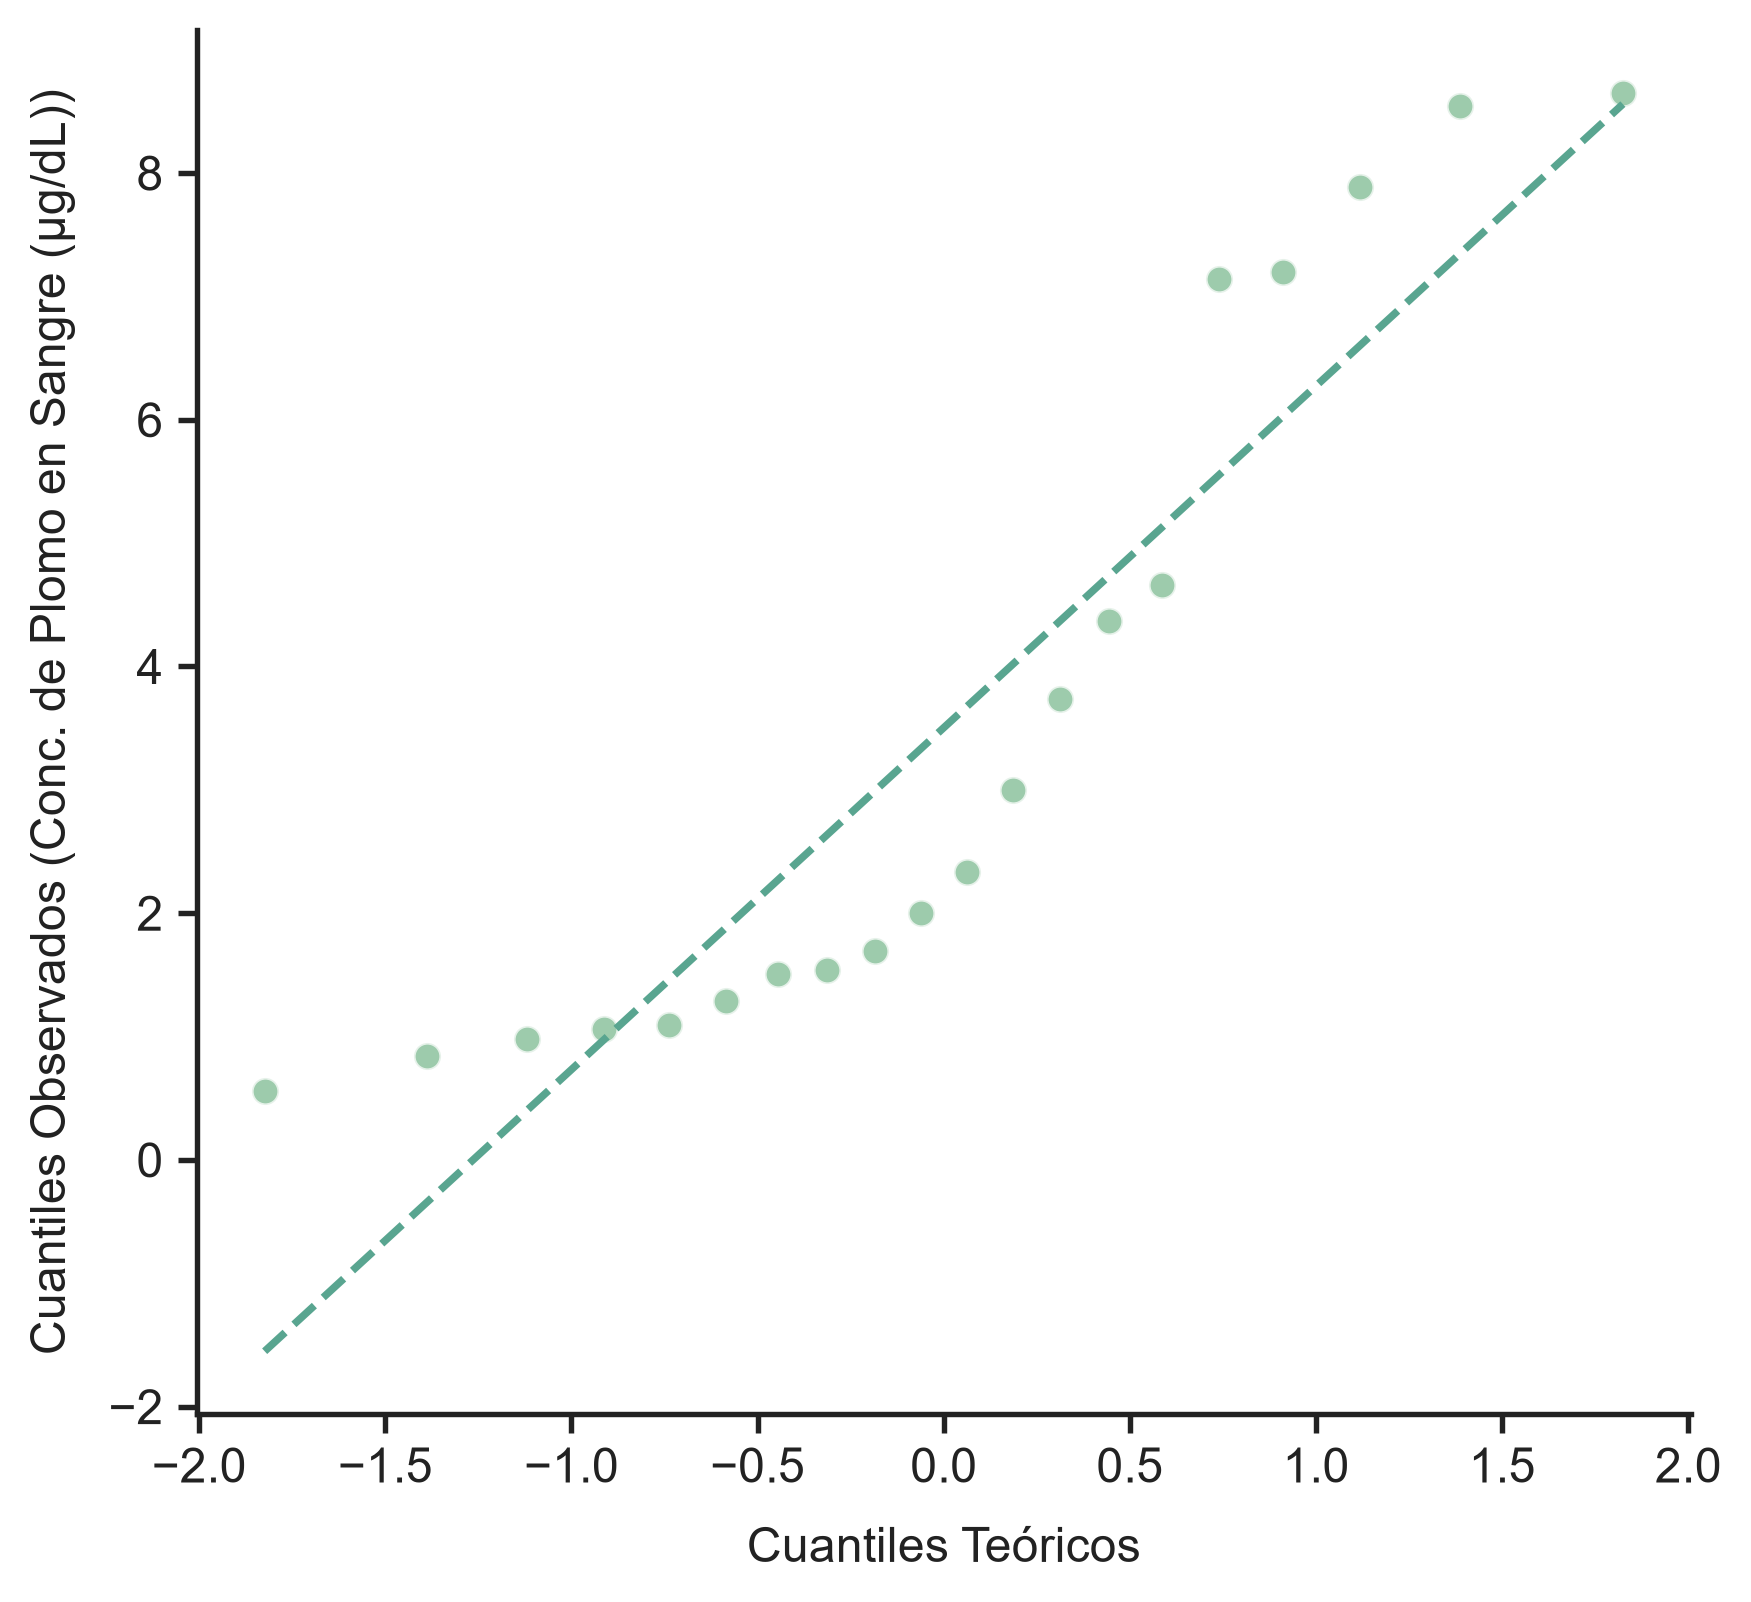

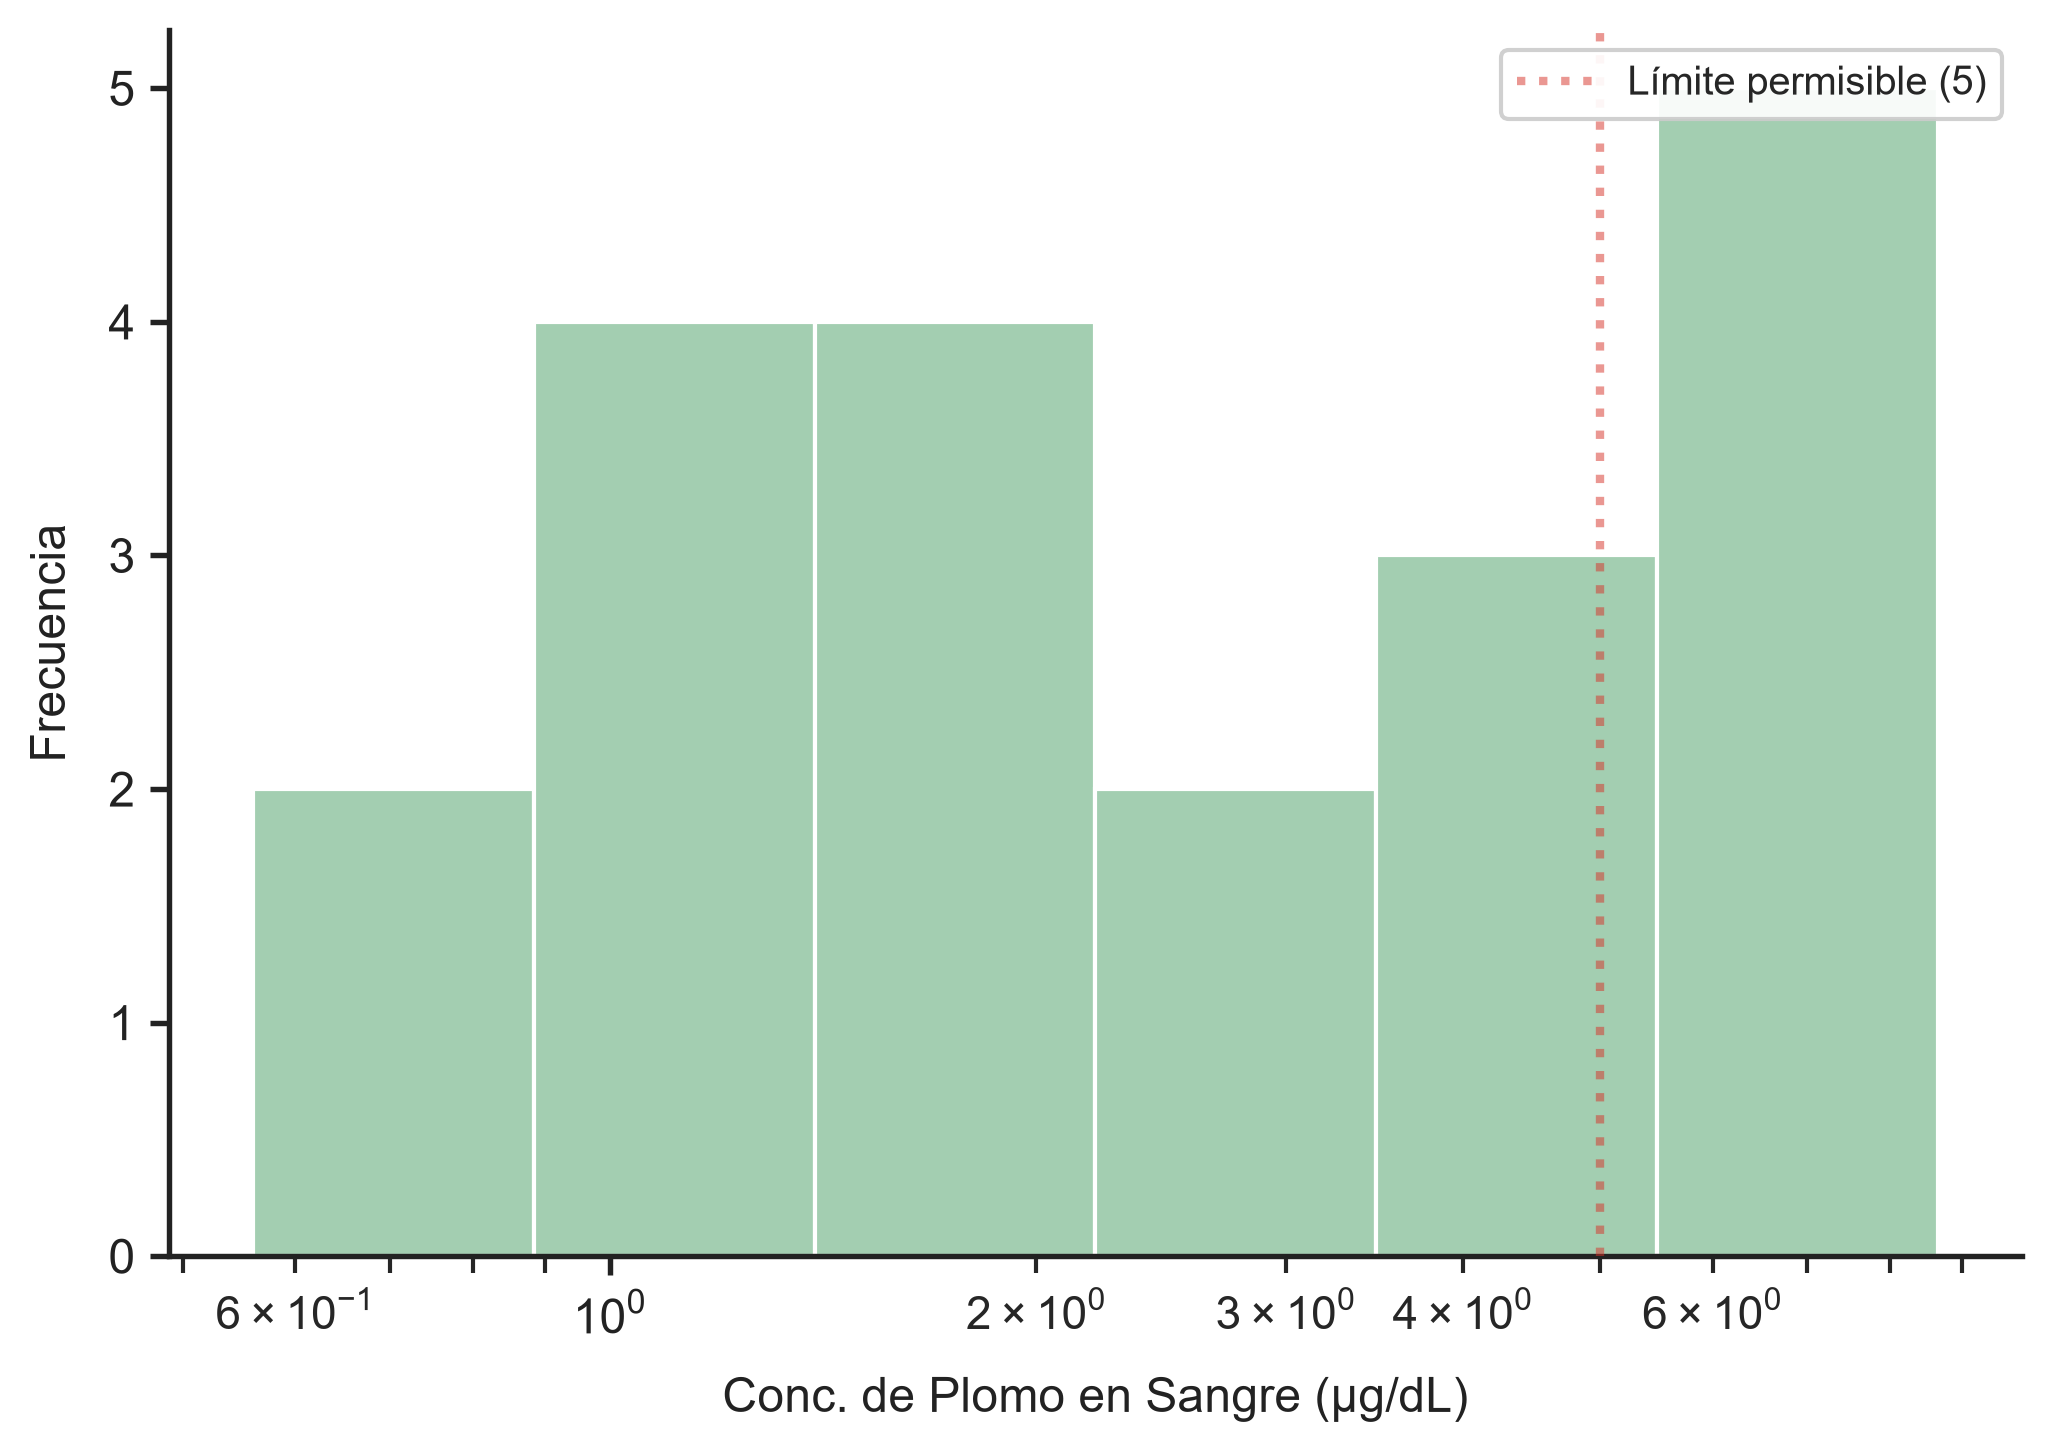

In [12]:
# Comparación Q-Q de Plomo en escala natural
fig_qq_pb_nat = uplots.plot_qq("Plomo_ug_dL")
fig_qq_pb_nat;

# Histograma de Plomo en escala logarítmica coordinada
fig_hist_pb_log = uplots.plot_histograms("Plomo_ug_dL", log_scale=True, show_limit=True)
fig_hist_pb_log;


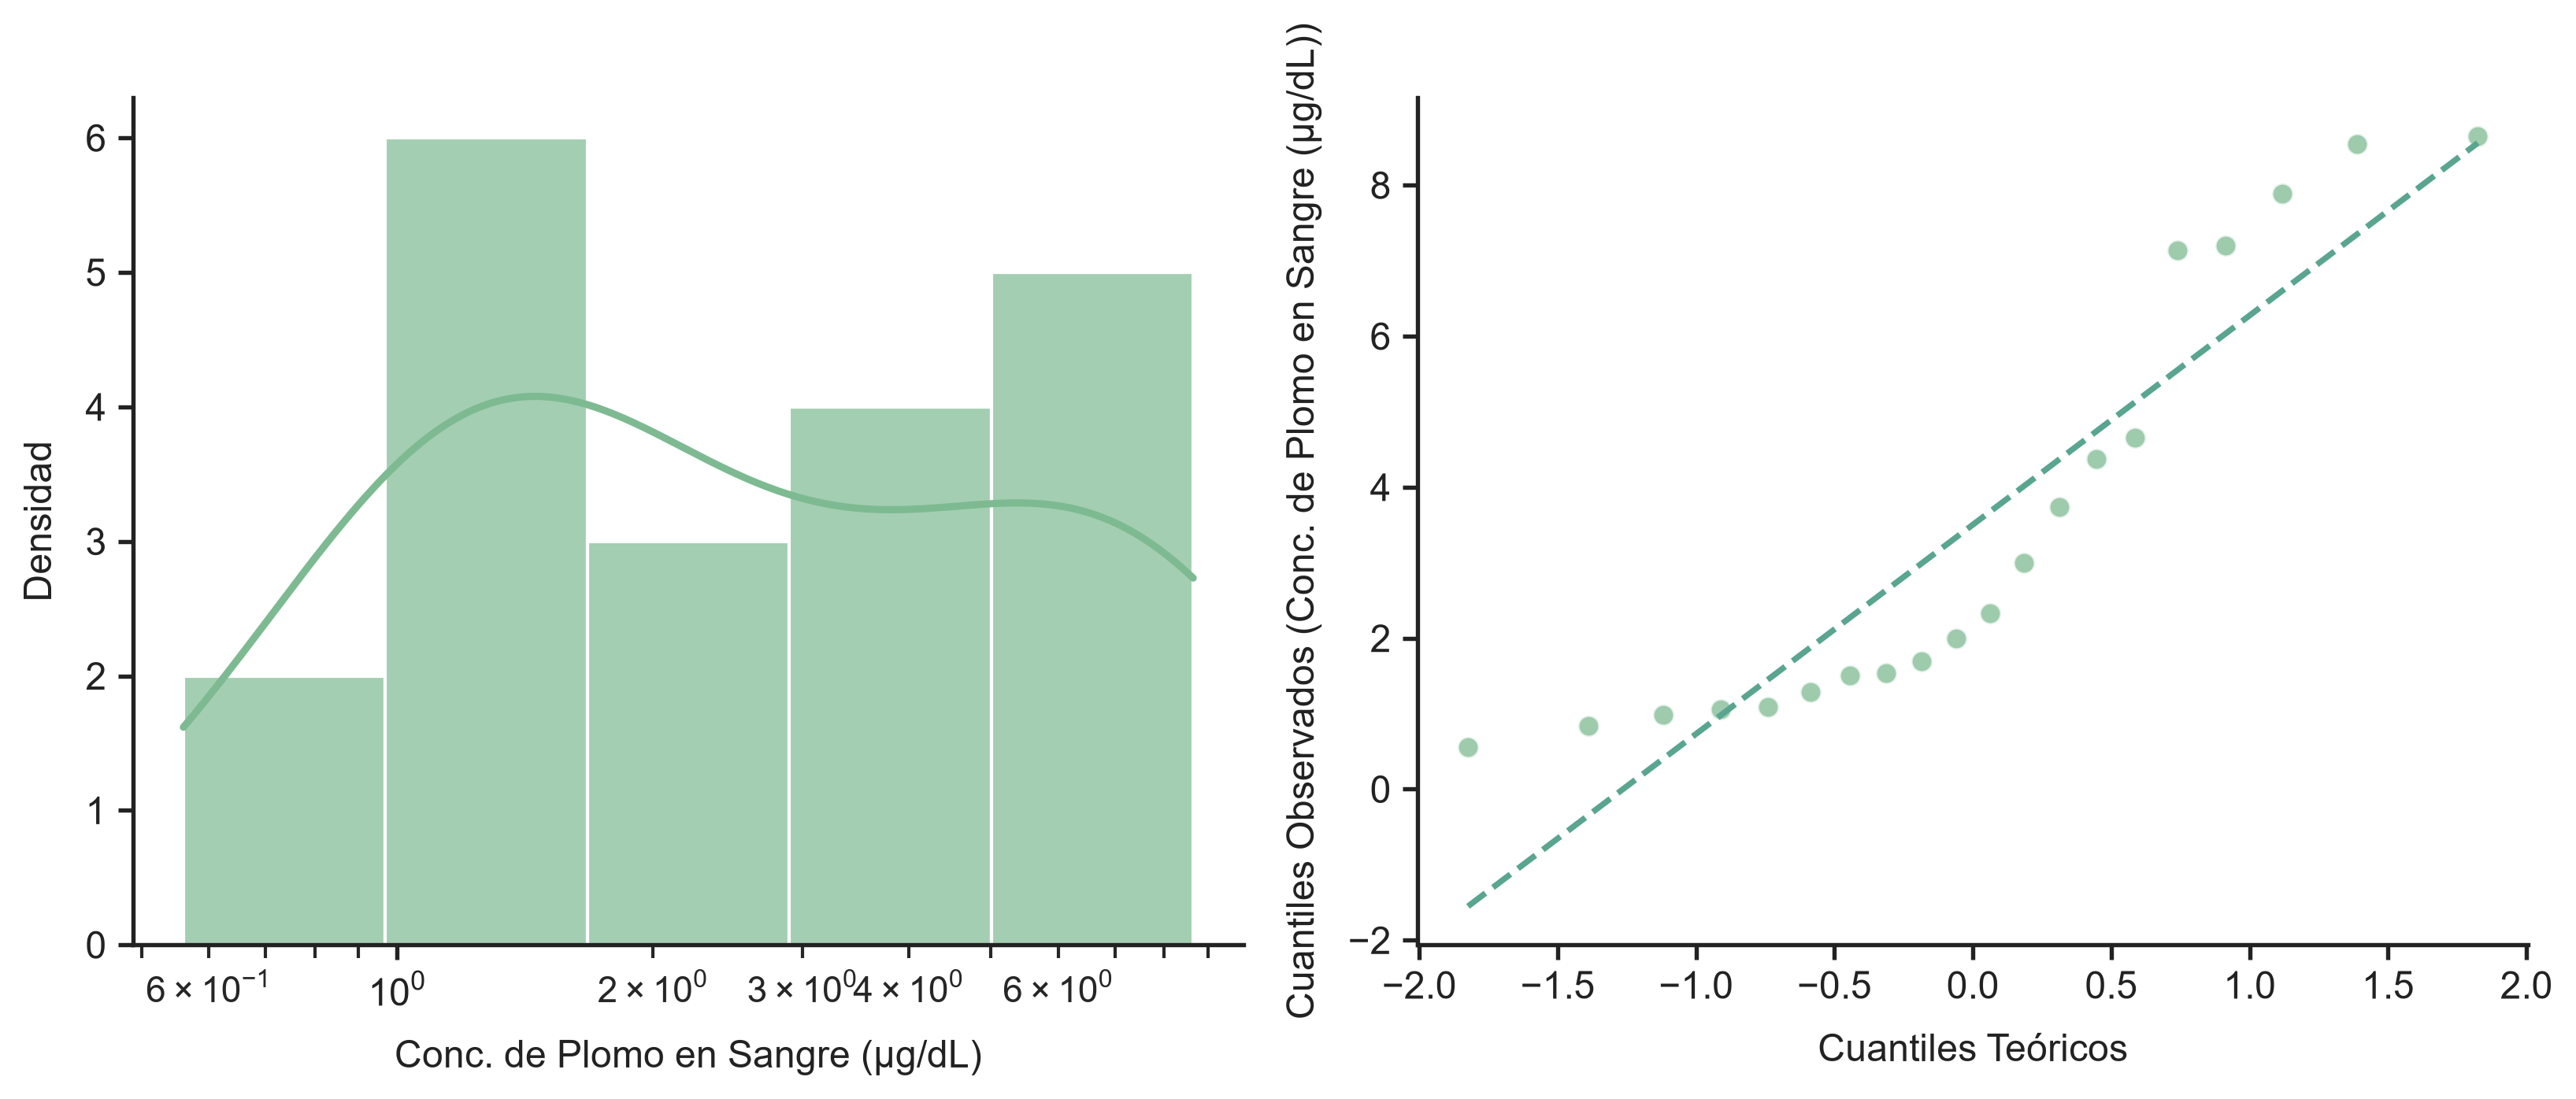

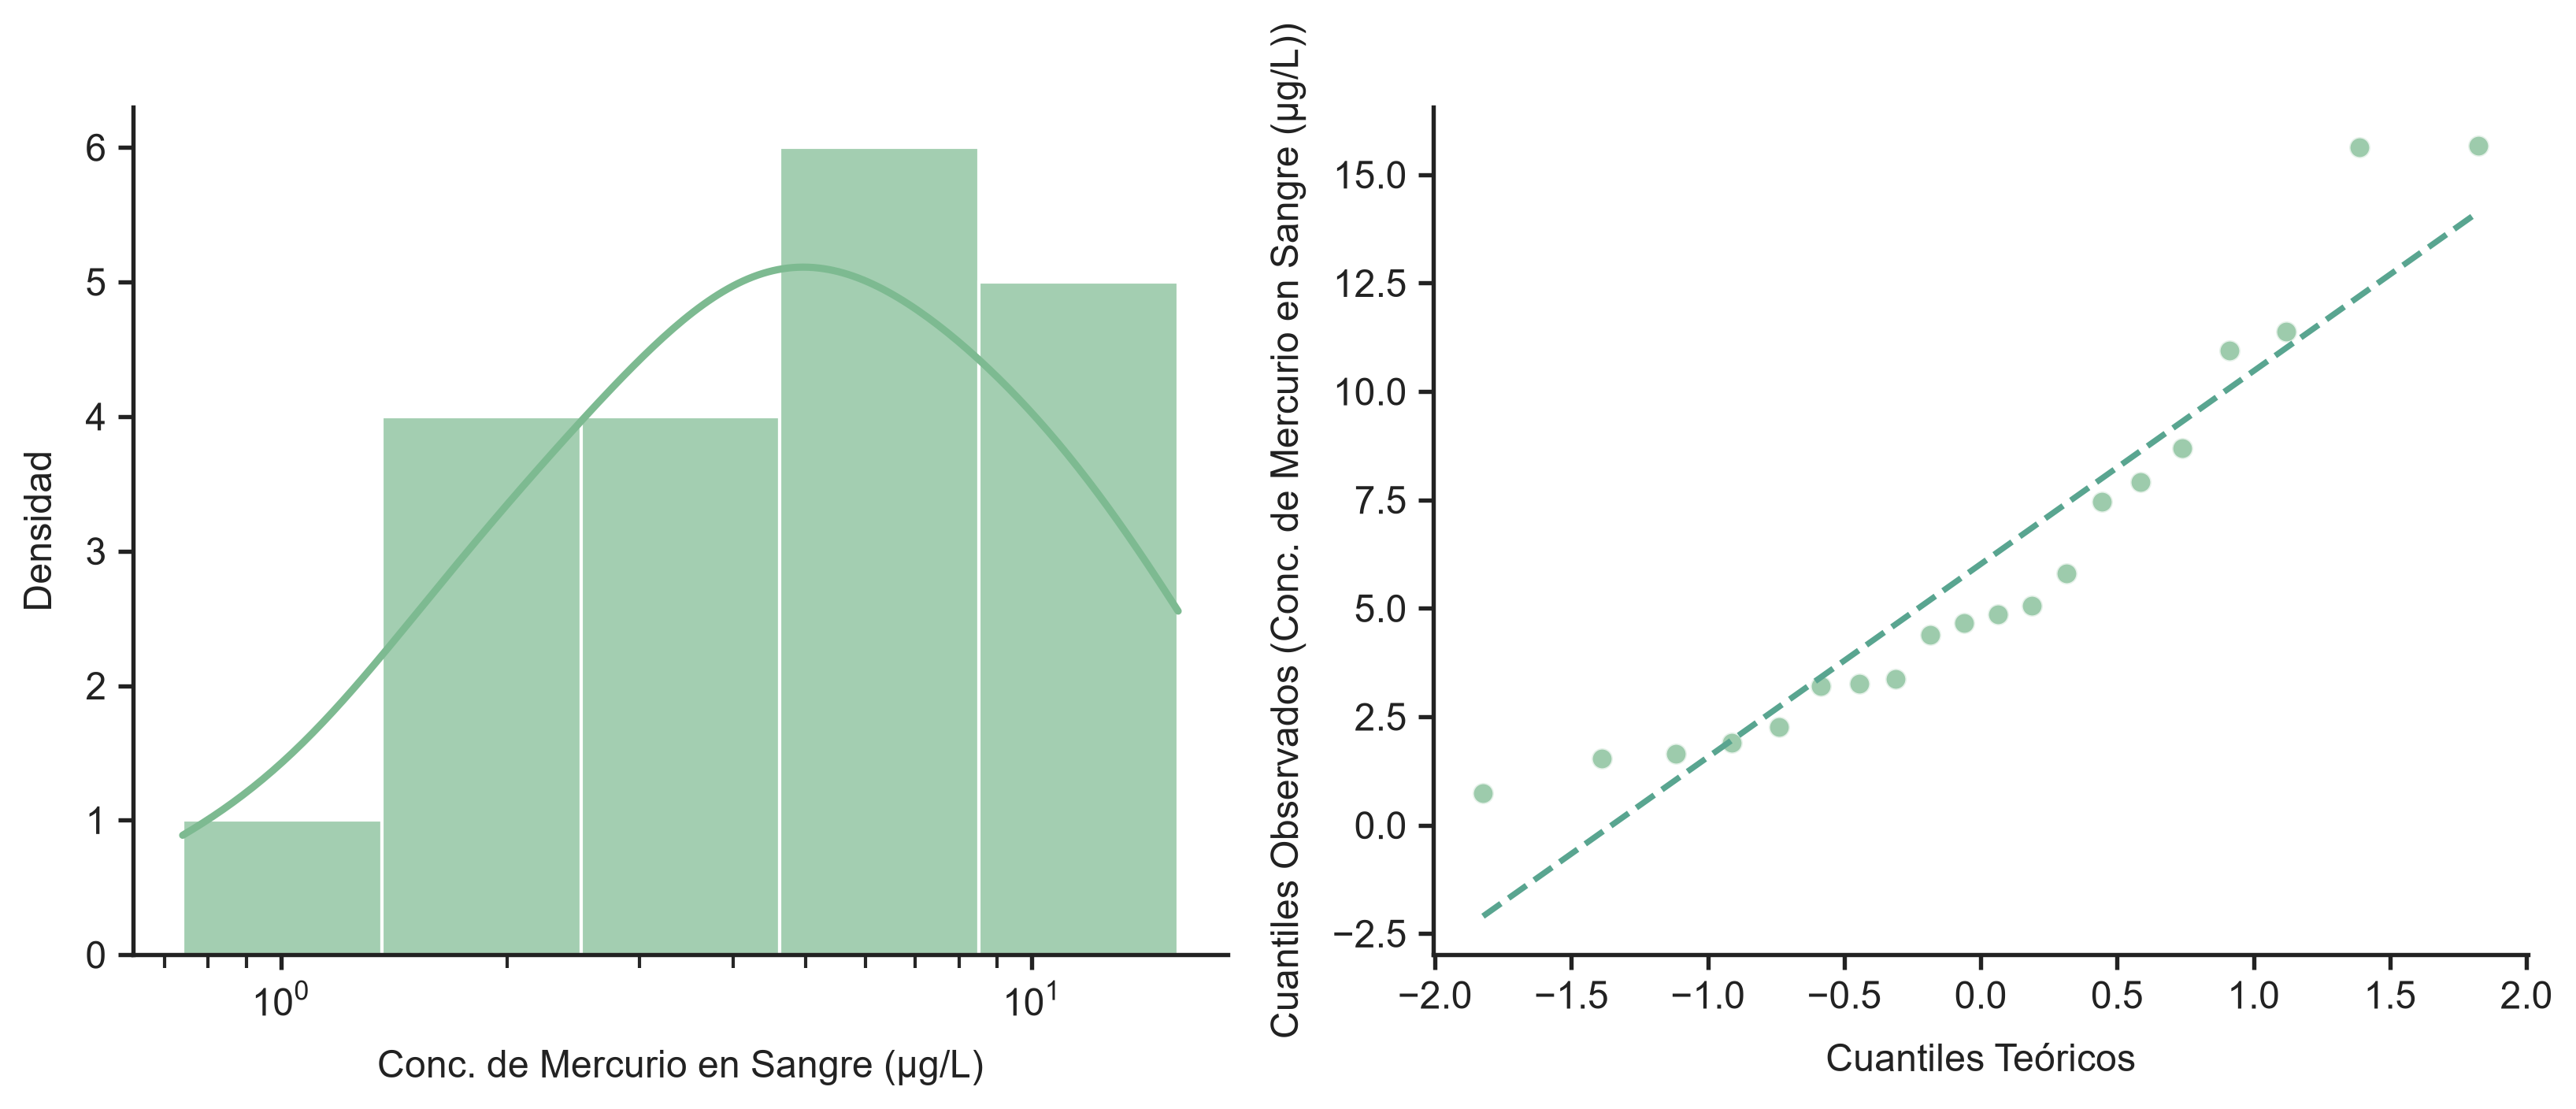

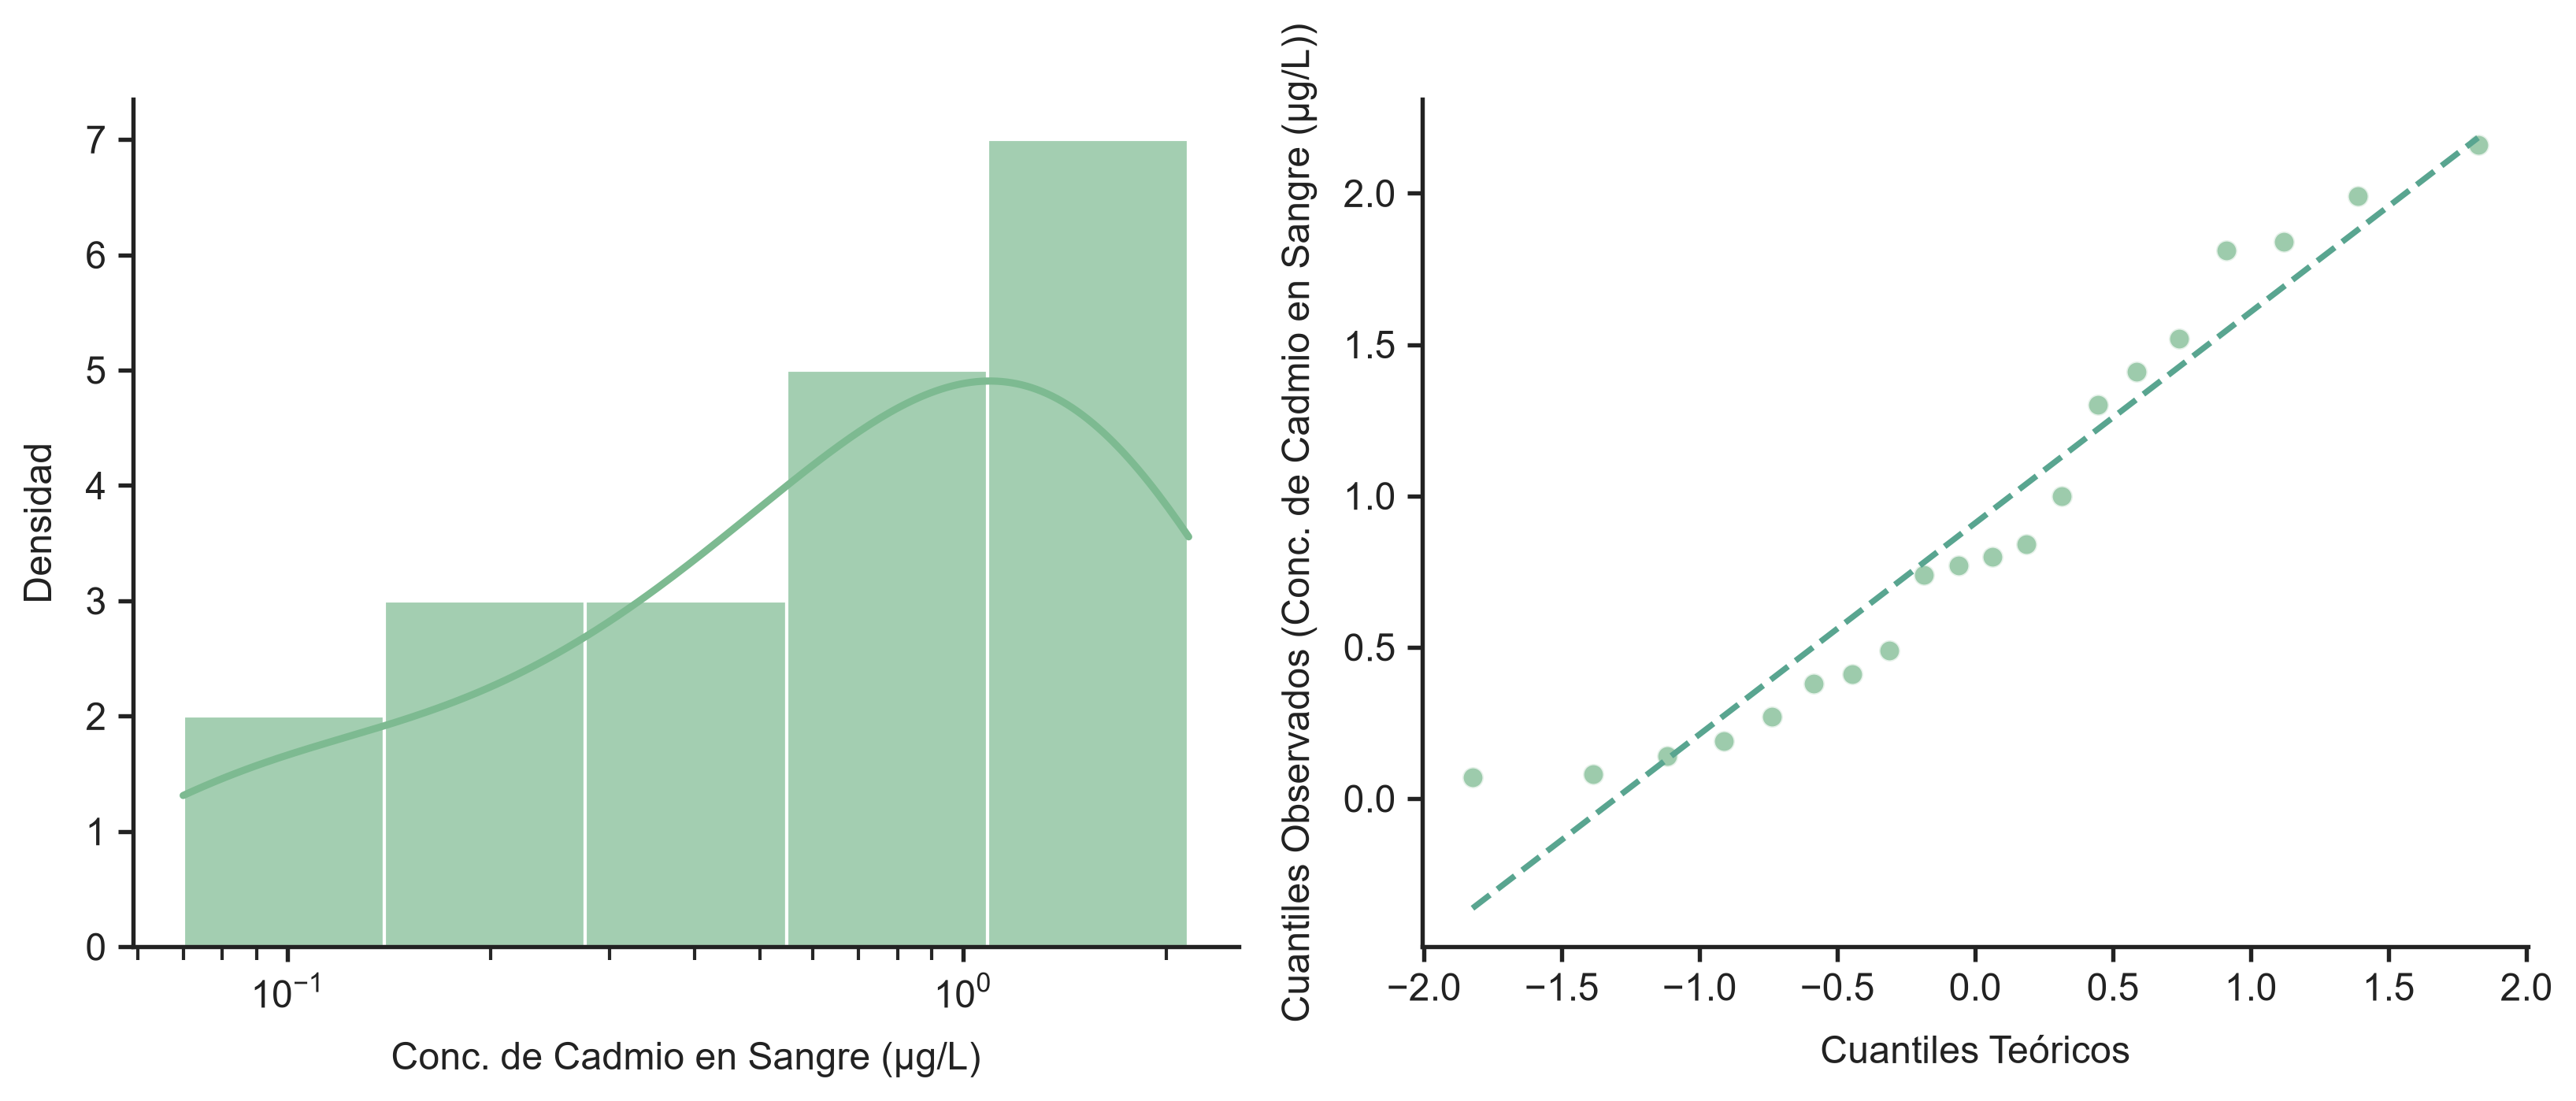

In [13]:
cols = ["Plomo", "Mercurio", "Cadmio",]
for col in cols:
    # 1. Crear la figura con 1 fila y 2 columnas
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(11, 4.5))
    
    # 2. Histograma en ax1
    uplots.plot_histograms(col, ax=ax1, log_scale=True, bins=5, kde=True)
    
    # 3. Gráfico Q-Q en ax2
    uplots.plot_qq(col, ax=ax2)
    
    # 4. Ajustar espaciado y mostrar
    fig.tight_layout()
    plt.show()

--- 
## 6. Evaluación Antropométrica e Índice de Masa Corporal (IMC) Pediátrico

El Índice de Masa Corporal ($\text{IMC} = \frac{\text{Peso (kg)}}{[\text{Talla (m)}]^2}$) en pediatría requiere ajuste por edad y sexo. 

El método `bmi_summary()` clasifica a cada paciente según las **Tablas de Crecimiento y Percentiles del CDC (2000 / 2022 Extendida)** específicas para la edad (en años) y sexo del menor:
- **Bajo peso**: $\text{Percentil} < 5$
- **Peso saludable**: $\text{Percentil}\ 5 \le p < 85$
- **Sobrepeso**: $\text{Percentil}\ 85 \le p < 95$
- **Obesidad**: $\text{Percentil} \ge 95$


In [14]:
# Resumen de clasificación nutricional pediátrica CDC con desglose individual
report_bmi = tables.bmi_summary(max_patient_rows=20)
report_bmi

<UnivariateTableReport shape=(5, 3) title='Clasificación del Índice de Masa Corporal (IMC) Pediátrico'>

--- 
## 7. Extracción de Datos Enriquecidos y Detalle Individual de Pacientes

A partir del reporte de IMC es posible extraer el `DataFrame` enriquecido con las columnas de cálculo biométrico (`Calculated_IMC`, `Percentil_CDC`, `Clasificacion_IMC`, `Estado_Nutricional`) para auditoría clínica o modelado estadístico posterior mediante `get_classified_df()`.


In [15]:
# Extraer el DataFrame con las clasificaciones individuales
df_pacientes = report_bmi.get_classified_df()
df_pacientes[["Muestra_Codificada", "Edad", "Sexo", "Peso_kg", "Altura_cm", "Calculated_IMC", "Clasificacion_IMC"]]

,Muestra_Codificada,Edad,Sexo,Peso_kg,Altura_cm,Calculated_IMC,Clasificacion_IMC
0,1,7,femenino,32.0,128.0,19.531250,Sobrepeso
1,2,8,masculino,21.0,125.0,13.440000,Bajo peso
2,3,9,masculino,31.0,141.0,15.592777,Normopeso
3,4,7,masculino,24.0,126.0,15.117158,Normopeso
4,5,6,femenino,19.0,117.0,13.879757,Normopeso
5,6,7,masculino,22.0,119.0,15.535626,Normopeso
6,7,9,femenino,26.0,132.0,14.921947,Normopeso
7,8,7,masculino,19.0,118.0,13.645504,Bajo peso
8,9,6,masculino,21.0,121.0,14.343283,Normopeso
9,10,5,femenino,15.0,108.0,12.860082,Bajo peso


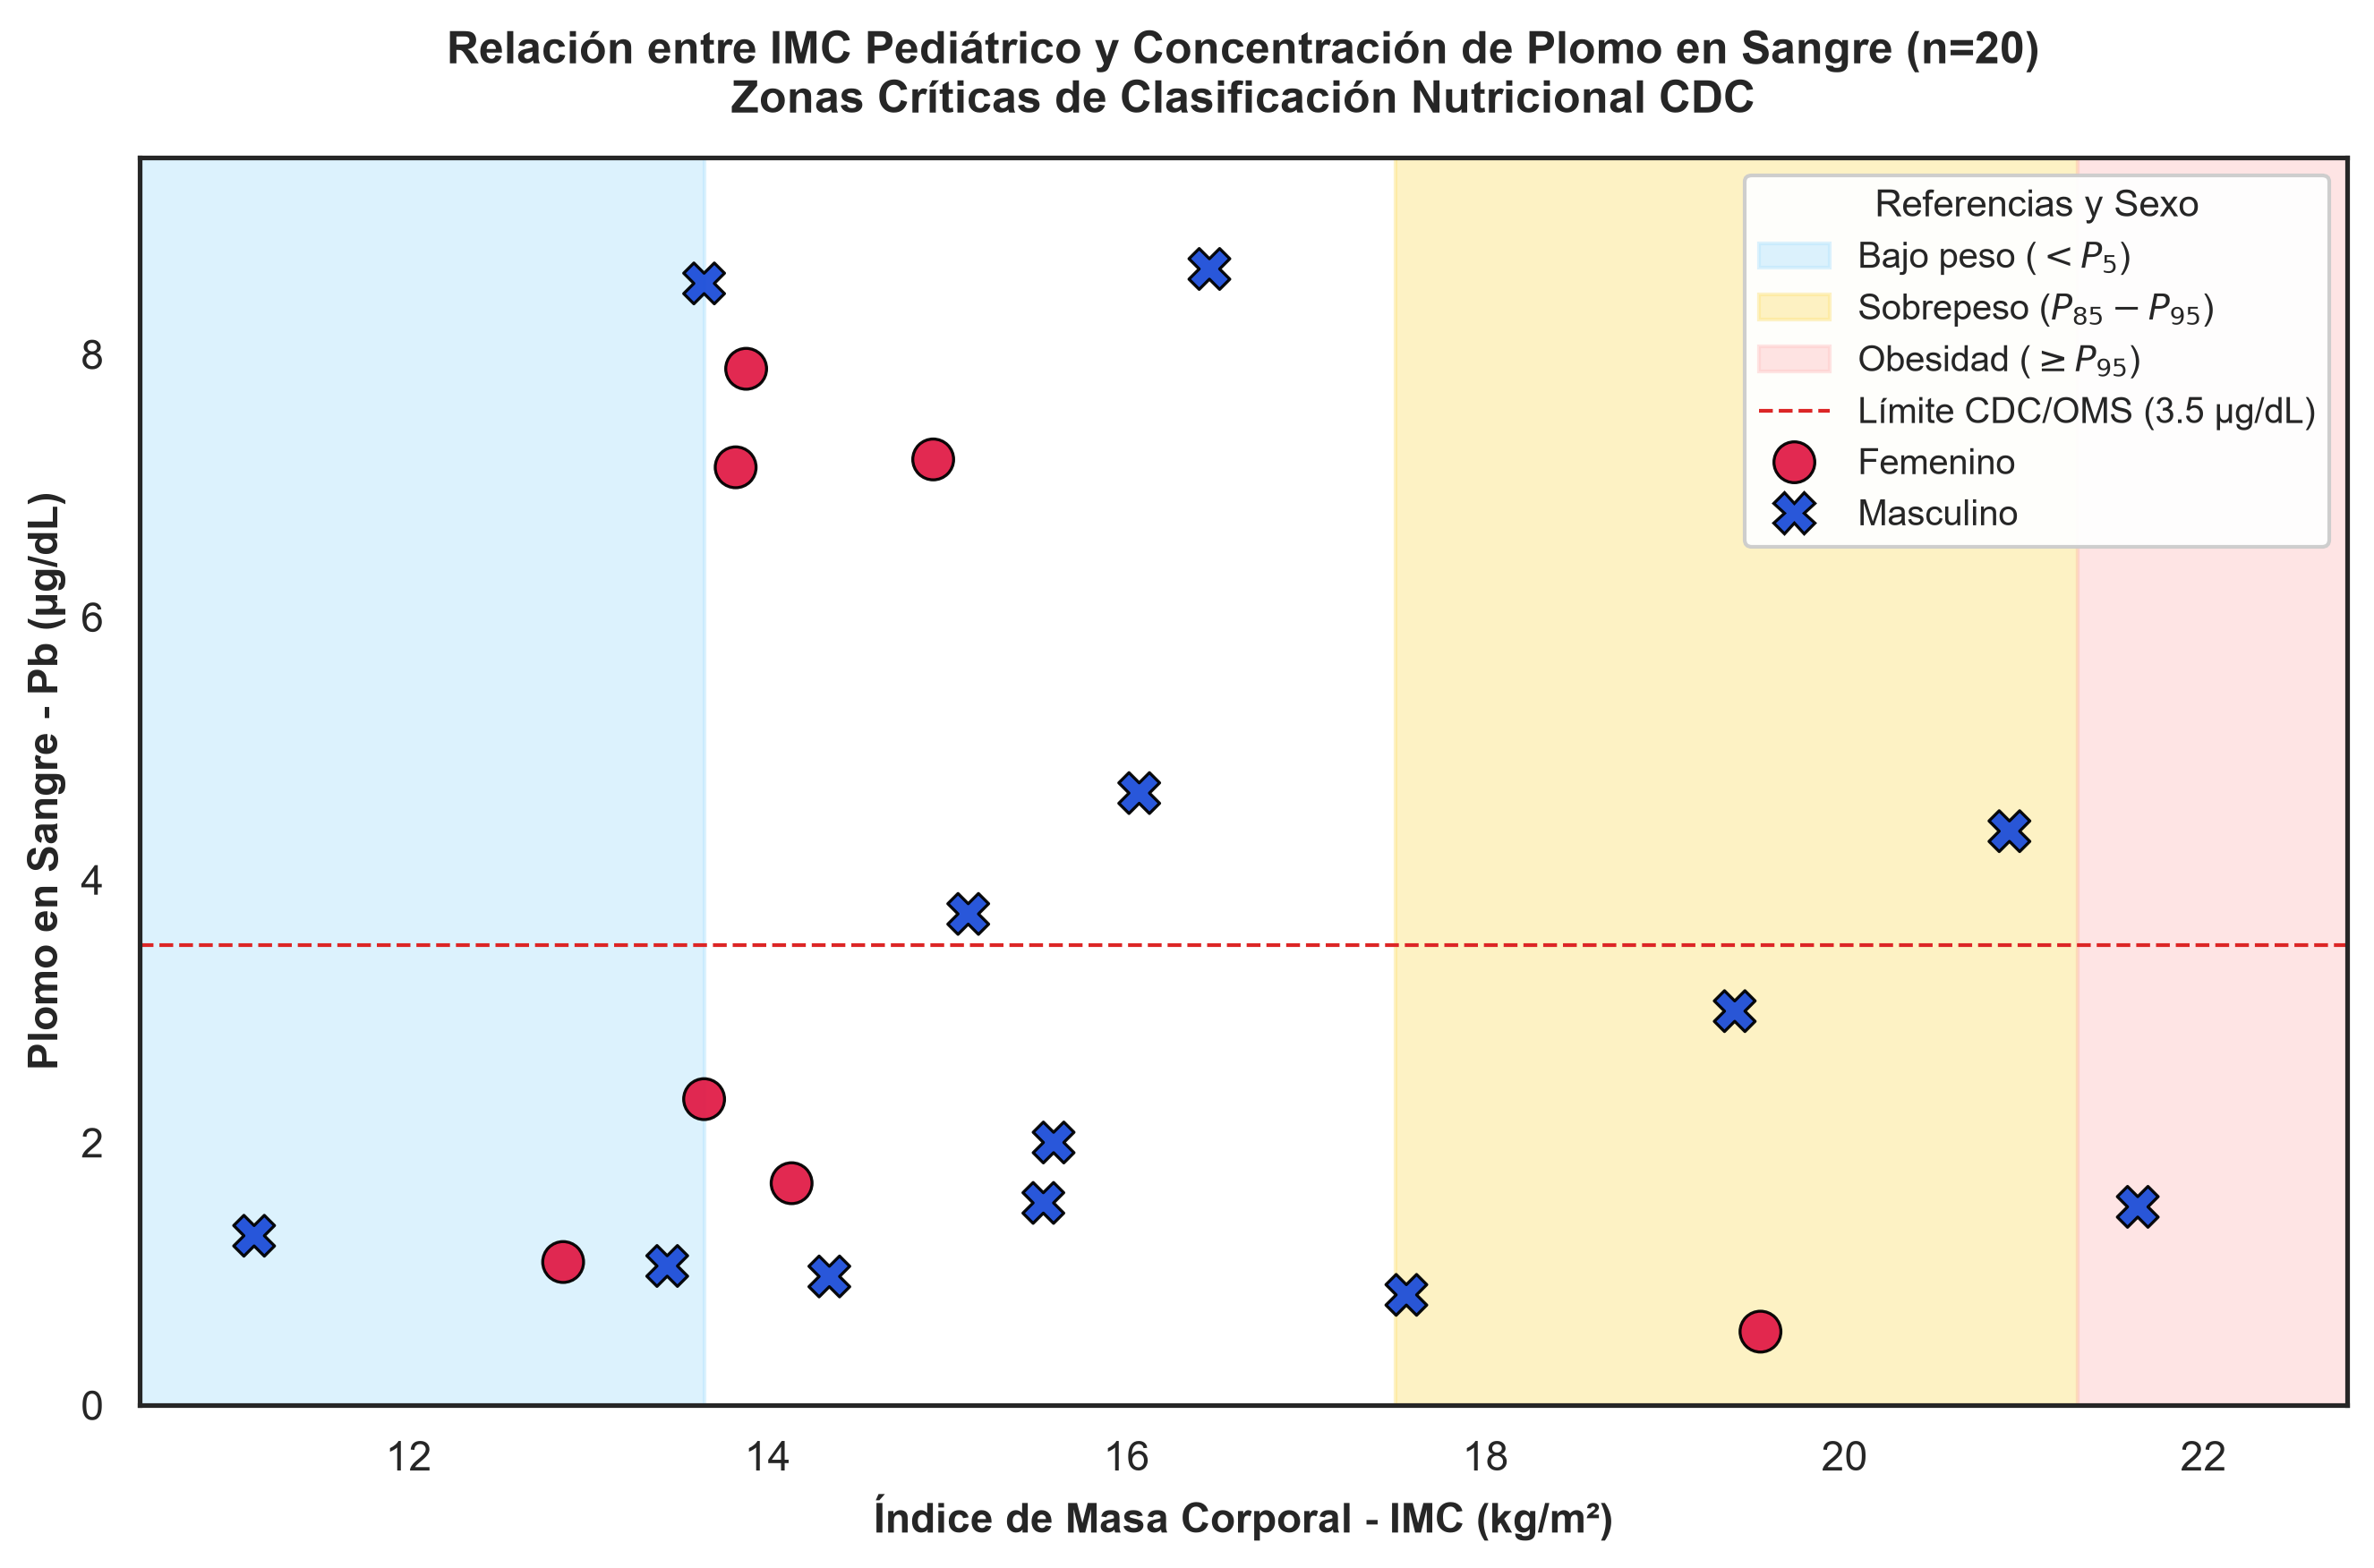

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Paleta de colores diferenciables por sexo (alto contraste)
palette_sexo = {
    "masculino": "#1d4ed8",  # Azul zafiro
    "femenino": "#e11d48",   # Rojo carmesí
}

# 2. Configuración de figura y lienzo
fig, ax = plt.subplots(figsize=(9, 6))
sns.set_theme(style="white", font="sans-serif")

# 3. Sombreado (fill con alpha=0.5) de clasificaciones críticas de IMC (CDC)
# - Bajo peso (< P5): Déficit ponderal
# - Sobrepeso (P85 a P95): Exceso moderado
# - Obesidad (>= P95): Exceso severo
ax.axvspan(10.5, 13.65, color="#bae6fd", alpha=0.5, label=r"Bajo peso ($< P_5$)", zorder=1)
ax.axvspan(17.5, 21.3, color="#fde68a", alpha=0.5, label=r"Sobrepeso ($P_{85}-P_{95}$)", zorder=1)
ax.axvspan(21.3, 23.0, color="#fecaca", alpha=0.5, label=r"Obesidad ($\geq P_{95}$)", zorder=1)

# 4. Línea de referencia / límite crítico de Plomo (CDC / OMS: 5.0 µg/dL)
limit_pb = 3.5
ax.axhline(
    y=limit_pb,
    color="#dc2626",
    linestyle="--",
    linewidth=1,
    label=f"Límite CDC/OMS ({limit_pb} μg/dL)",
    zorder=2
)

# 5. Gráfico de dispersión de pacientes
sns.scatterplot(
    data=df_pacientes, 
    x="Calculated_IMC", 
    y="Plomo_ug_dL",
    hue="Sexo",
    style="Sexo",
    palette=palette_sexo,
    s=120,
    alpha=0.95,
    edgecolor="black",
    linewidth=0.8,
    ax=ax,
    zorder=3
)

# 6. Etiquetas descriptivas y título formal
ax.set_title(
    "Relación entre IMC Pediátrico y Concentración de Plomo en Sangre (n=20)\nZonas Críticas de Clasificación Nutricional CDC", 
    fontsize=12, 
    fontweight="bold", 
    pad=12
)
ax.set_xlabel("Índice de Masa Corporal - IMC (kg/m²)", fontsize=11, fontweight="bold")
ax.set_ylabel("Plomo en Sangre - Pb (μg/dL)", fontsize=11, fontweight="bold")

ax.set_xlim(10.5, 22.8)
ax.set_ylim(0, 9.5)

# 7. Formato de leyenda integrada
handles, labels = ax.get_legend_handles_labels()
labels_fmt = [l.capitalize() if l in ["masculino", "femenino"] else l for l in labels]
ax.legend(
    handles=handles, 
    labels=labels_fmt, 
    title="Referencias y Sexo", 
    title_fontsize=10, 
    fontsize=9.5, 
    loc="upper right", 
    frameon=True, 
    framealpha=0.95
)

plt.tight_layout()
plt.show()


--- 
## 8. Exportación de Tablas y Resultados

Todos los reportes generados por `UnivariateTables` (`UnivariateTableReport`) admiten exportación inmediata a múltiples formatos con calidad editorial:
- **HTML interactivo Booktabs**: `to_html("archivo.html", full_page=True)`
- **Libros de Excel con formato**: `to_excel("archivo.xlsx", sheet_name="...")`
- **Archivos CSV estructurados**: `to_csv("archivo.csv")`
- **DataFrames de Pandas**: `to_dataframe()`


In [20]:
# 1. Exportar reporte toxicológico de metales a HTML interactivo Booktabs
report_metals.to_html("reporte_metales.html", full_page=True)

# 2. Exportar reporte categórico y numérico a Excel
report_cat.to_excel("reporte_categorico.xlsx", sheet_name="Categoricas")
report_num.to_excel("reporte_numerico.xlsx", sheet_name="Numericas")

# 3. Exportar clasificación de pacientes a CSV
df_pacientes.to_csv("pacientes_clasificados_imc.csv", index=False)

print("¡Reportes univariantes exportados exitosamente a HTML, Excel y CSV!")

¡Reportes univariantes exportados exitosamente a HTML, Excel y CSV!
